¿Desea hacer un cálculo para una hora específica (h), un día específico (d) o para todo el año (a)? (h/d/a): a
Por favor introduzca el año: 2025
Por favor introduzca el valor de la latitud (en grados [-90 a 90]): 4
Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): 10
Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): 0

Calculando parámetros para el año 2025:
------------------------------------------------------------------------------------
Día | Excentricidad | Radio (10^6 km) | Declinación (°) | G_mediodía (W/m²)
----|---------------|-----------------|-----------------|-------------------
  1 |        1.0330 |         147.057 |          -23.01 |            960.17
  2 |        1.0330 |         147.057 |          -22.93 |            960.33
  3 |        1.0330 |         147.057 |          -22.84 |            960.51
  4 |        1.0329 |         147.059 |  

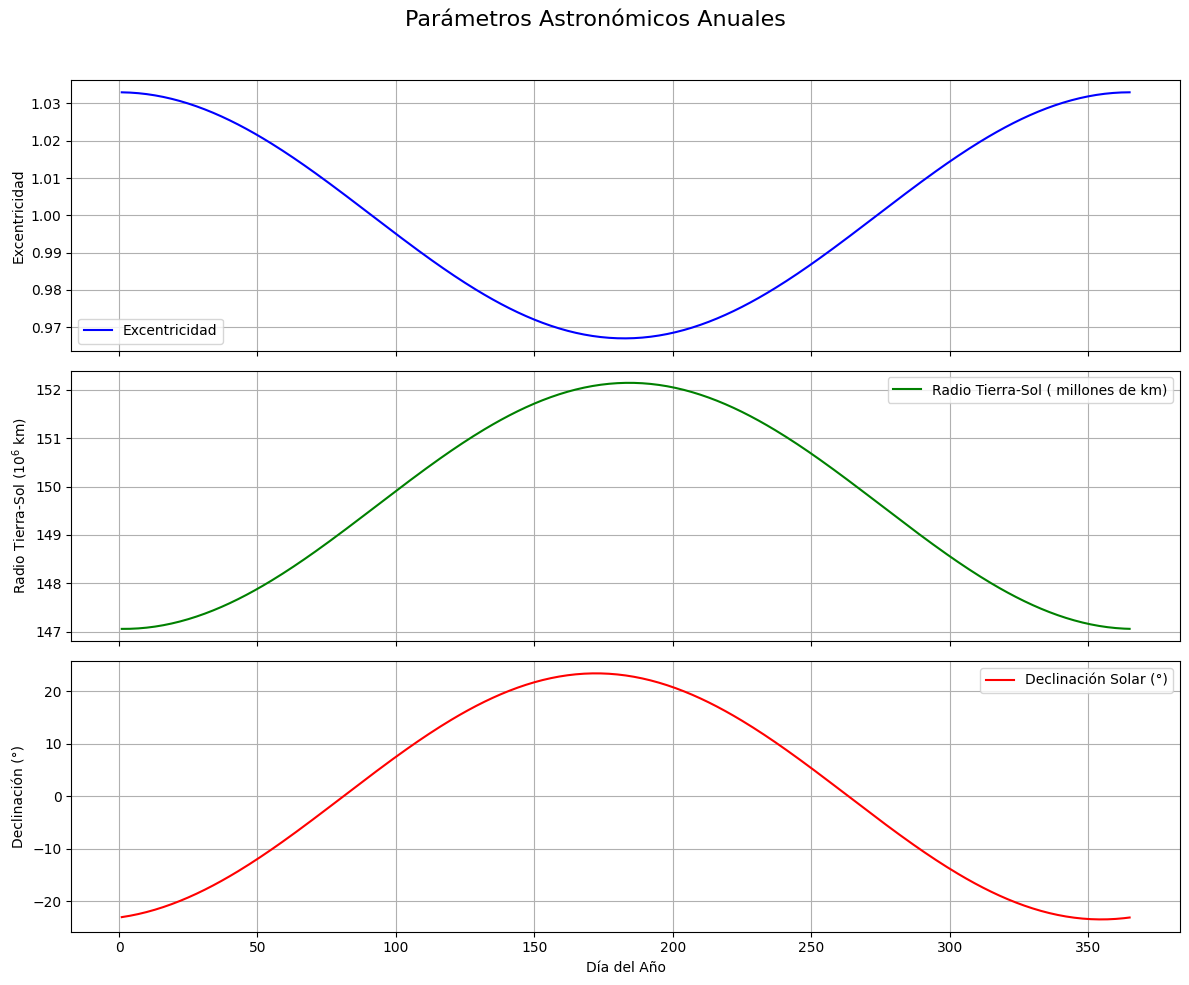

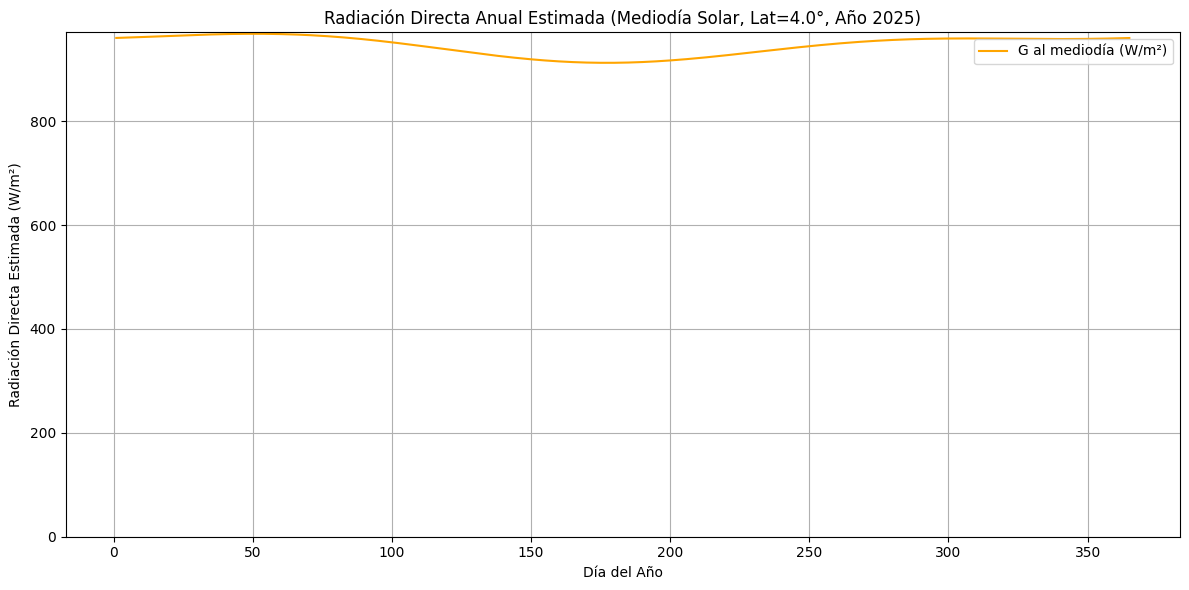

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definiendo las constantes.
Bo = 1367  # W/m^2
ro = 1.496e11  # Radio Tierra-Sol medio (m)

def es_año_bisiesto(año):
    if año % 4 == 0:
        if año % 100 == 0:
            return año % 400 == 0
        else:
            return True
    else:
        return False

def dia_del_año(dia, mes, año):
    dias_por_mes = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    if es_año_bisiesto(año):
        dias_por_mes[2] = 29

    if not (1 <= mes <= 12 and 1 <= dia <= dias_por_mes[mes]):
        return f"Fecha Inválida: Día {dia} o Mes {mes} fuera de rango para el año {año}."

    numero_dia = sum(dias_por_mes[:mes]) + dia
    return numero_dia

# --- Funciones de Cálculo Solar ---
def calcular_excentricidad(dn_final):

    angulo_en_radianes = np.radians((360 * dn_final) / 365)
    return 1 + 0.033 * np.cos(angulo_en_radianes)

def calcular_radio_tierra_sol(dn_final):

    angulo_en_radianes2 = np.radians((360 * (dn_final - 93)) / 365)

    return ro * (1 + 0.017 * np.sin(angulo_en_radianes2))


def calcular_declinacion(dn_final):

    return 23.45 * np.sin(np.radians((360 / 365) * (dn_final - 81)))

def calcular_parametros_hora_especifica(dn_final, H_local, phi_grados, beta_grados, azimut_superficie_grados, declinacion_grados_precal=None, excentricidad_precal=None):

    if declinacion_grados_precal is None:
        declinacion_grados = calcular_declinacion(dn_final)
    else:
        declinacion_grados = declinacion_grados_precal

    if excentricidad_precal is None:
        excentricidad = calcular_excentricidad(dn_final)
    else:
        excentricidad = excentricidad_precal

    w_grados = 15 * (H_local - 12)

    phi_rad = np.radians(phi_grados)
    beta_rad = np.radians(beta_grados)
    azimut_superficie_rad = np.radians(azimut_superficie_grados)
    declinacion_rad = np.radians(declinacion_grados)
    w_rad = np.radians(w_grados)

    cos_theta_s = (
        np.sin(declinacion_rad) * np.sin(phi_rad) * np.cos(beta_rad)
        - np.sign(phi_grados) * np.sin(declinacion_rad) * np.cos(phi_rad) * np.sin(beta_rad) * np.cos(azimut_superficie_rad)
        + np.cos(declinacion_rad) * np.cos(phi_rad) * np.cos(beta_rad) * np.cos(w_rad)
        + np.sign(phi_grados) * np.cos(declinacion_rad) * np.sin(beta_rad) * np.cos(azimut_superficie_rad) * np.cos(w_rad)
        + np.cos(declinacion_rad) * np.sin(w_rad) * np.sin(beta_rad)
    )
    cos_theta_s = np.clip(cos_theta_s, -1.0, 1.0)


    cos_theta_zs = (
        np.sin(declinacion_rad) * np.sin(phi_rad)
        + np.cos(declinacion_rad) * np.cos(phi_rad) * np.cos(w_rad)
    )
    cos_theta_zs = np.clip(cos_theta_zs, -1.0, 1.0)

    am = None
    g = 0.0

    if cos_theta_zs > 1e-6:
        am = 1 / cos_theta_zs

        am = min(am, 38)

        if cos_theta_s > 1e-6:
            transmitancia_directa = 0.7**(am**0.678)
            g = Bo * excentricidad * transmitancia_directa * cos_theta_s
            g = max(0, g)
        else:
            g = 0.0
    else:
        g = 0.0


    return w_grados, cos_theta_s, cos_theta_zs, am, g

# --- Funciones de Graficación ---
def graficar_anual_fijos(dias_año_num, excentricidades, radios_km, declinaciones, titulo_base=""):
    fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"{titulo_base}Parámetros Astronómicos Anuales", fontsize=16)

    axs[0].plot(dias_año_num, excentricidades, label='Excentricidad', color='blue')
    axs[0].set_ylabel('Excentricidad')
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(dias_año_num, radios_km, label='Radio Tierra-Sol ( millones de km)', color='green')
    axs[1].set_ylabel('Radio Tierra-Sol (10$^6$ km)')
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(dias_año_num, declinaciones, label='Declinación Solar (°)', color='red')
    axs[2].set_ylabel('Declinación (°)')
    axs[2].set_xlabel('Día del Año')
    axs[2].grid(True)
    axs[2].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def graficar_radiacion_global_anual(dias_año_num, G_anual, titulo="Radiación Directa Anual Estimada (Mediodía Solar)"):
    plt.figure(figsize=(12, 6))

    valid_indices = ~np.isnan(G_anual)
    if np.any(valid_indices):
        plt.plot(dias_año_num[valid_indices], G_anual[valid_indices], label='G al mediodía (W/m²)', color='orange')
    else:
        plt.plot([],[], label='G al mediodía (W/m²)', color='orange')

    plt.title(titulo)
    plt.xlabel('Día del Año')
    plt.ylabel('Radiación Directa Estimada (W/m²)')
    plt.legend()
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()

def graficar_radiacion_global_diaria(horas_dia, G_diaria, titulo="Radiación Directa Diaria Estimada"):
    plt.figure(figsize=(12, 7))
    G_diaria_np = np.array(G_diaria)
    horas_dia_np = np.array(horas_dia)


    plt.plot(horas_dia_np, G_diaria_np, label='G (W/m²)', color='purple')

    plt.title(titulo)
    plt.xlabel('Hora Local (decimal)')
    plt.ylabel('Radiación Directa Estimada (W/m²)')
    plt.xticks(np.arange(0, 25, 2))
    plt.legend()
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.xlim(0, 24)
    plt.tight_layout()
    plt.show()


def main():
    tipo_calculo = input("¿Desea hacer un cálculo para una hora específica (h), un día específico (d) o para todo el año (a)? (h/d/a): ").lower()

    if tipo_calculo not in ['h', 'd', 'a']:
        print("Tipo de cálculo no válido. Seleccione 'h', 'd' o 'a'.")
        return


    if tipo_calculo == 'a':
        año = int(input("Por favor introduzca el año: "))
        phi_grados = float(input("Por favor introduzca el valor de la latitud (en grados [-90 a 90]): "))
        beta_grados = float(input("Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): "))
        azimut_superficie_grados = float(input("Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): "))
    elif tipo_calculo == 'd':
        fecha_str = input("Por favor introduce la fecha (DD MM): ")
        año = int(input("Por favor introduzca el año: "))
        try:
            dia_n, mes_n = fecha_str.split()
            dia = int(dia_n)
            mes = int(mes_n)
        except ValueError:
            print("Formato de fecha incorrecto. Use DD MM.")
            return
        dn_final = dia_del_año(dia, mes, año)
        if isinstance(dn_final, str):
            print(dn_final)
            return

        phi_grados = float(input("Por favor introduzca el valor de la latitud (en grados [-90 a 90]): "))
        beta_grados = float(input("Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): "))
        azimut_superficie_grados = float(input("Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): "))

    elif tipo_calculo == 'h':
        fecha_str = input("Por favor introduce la fecha (DD MM): ")
        año = int(input("Por favor introduzca el año: "))
        try:
            dia_n, mes_n = fecha_str.split()
            dia = int(dia_n)
            mes = int(mes_n)
        except ValueError:
            print("Formato de fecha incorrecto. Use DD MM.")
            return
        dn_final = dia_del_año(dia, mes, año)
        if isinstance(dn_final, str):
            print(dn_final)
            return

        phi_grados = float(input("Por favor introduzca el valor de la latitud (en grados [-90 a 90]): "))
        beta_grados = float(input("Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): "))
        azimut_superficie_grados = float(input("Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): "))
        H_local = float(input("Por favor introduzca el valor de la hora local (en horas decimales, e.g., 13.5 para 1:30 PM): "))



    if tipo_calculo == 'a':
        num_dias_año = 366 if es_año_bisiesto(año) else 365
        dias_año_indices = np.arange(1, num_dias_año + 1)

        excentricidades_anuales = []
        radios_anuales_km = []
        declinaciones_anuales = []
        G_mediodia_anual = []

        print(f"\nCalculando parámetros para el año {año}:")
        print("------------------------------------------------------------------------------------")
        print("Día | Excentricidad | Radio (10^6 km) | Declinación (°) | G_mediodía (W/m²)")
        print("----|---------------|-----------------|-----------------|-------------------")

        for dn in dias_año_indices:
            exc = calcular_excentricidad(dn)
            rad_m = calcular_radio_tierra_sol(dn)
            dec = calcular_declinacion(dn)


            _, _, _, _, g_mediodia = calcular_parametros_hora_especifica(dn, 12.0, phi_grados, beta_grados, azimut_superficie_grados, dec, exc)

            excentricidades_anuales.append(exc)
            radios_anuales_km.append(rad_m / 1e9)
            declinaciones_anuales.append(dec)
            G_mediodia_anual.append(g_mediodia if g_mediodia is not None else np.nan)

            print(f"{dn:3d} | {exc:13.4f} | {rad_m/1e9:15.3f} | {dec:15.2f} | {(f'{g_mediodia:.2f}' if g_mediodia is not None else 'N/A'):>17}")
        print("------------------------------------------------------------------------------------")

        graficar_anual_fijos(dias_año_indices, excentricidades_anuales, radios_anuales_km, declinaciones_anuales)
        graficar_radiacion_global_anual(dias_año_indices, np.array(G_mediodia_anual),
                                        titulo=f"Radiación Directa Anual Estimada (Mediodía Solar, Lat={phi_grados}°, Año {año})")

    elif tipo_calculo == 'd':
        print(f"\nCalculando para el día {dia}/{mes}/{año} (Día del año: {dn_final}):")
        print(f"Latitud: {phi_grados}°, Inclinación: {beta_grados}°, Azimut Superficie: {azimut_superficie_grados}°")
        print("--------------------------------------------------------------------------")
        print("Hora    | w (°) | cos(θs) | cos(θzs) |   AM   | G (W/m²)")
        print("--------|-------|---------|----------|--------|----------")

        horas_decimales_dia = np.arange(0, 24, 2/60) # Cada 2 minutos
        G_diaria = []

        exc_dia = calcular_excentricidad(dn_final)
        dec_dia = calcular_declinacion(dn_final)
        print(f"Excentricidad del día: {exc_dia:.4f}, Declinación del día: {dec_dia:.2f}°\n")

        for H_actual in horas_decimales_dia:
            w_grados, cos_theta_s, cos_theta_zs, am, g = \
                calcular_parametros_hora_especifica(dn_final, H_actual, phi_grados, beta_grados, azimut_superficie_grados, dec_dia, exc_dia)

            hora_h = int(H_actual)
            min_m = int(round((H_actual * 60) % 60))
            hora_reloj_str = f"{hora_h:02d}:{min_m:02d}"

            G_diaria.append(g if g is not None else 0)

            am_str = f"{am:6.2f}" if am is not None else "   -   "
            g_str = f"{g:8.2f}" if g is not None else "    -   "
            print(f"{hora_reloj_str:8}| {w_grados:5.1f} | {cos_theta_s:7.3f} | {cos_theta_zs:8.3f} | {am_str} | {g_str}")
        print("--------------------------------------------------------------------------")

        graficar_radiacion_global_diaria(horas_decimales_dia, G_diaria,
                                         titulo=f"Radiación Directa Estimada - {dia}/{mes}/{año} (Lat={phi_grados}°)")


        print("\nGenerando gráfica de radiación anual (mediodía) para contexto...")
        num_dias_año_actual = 366 if es_año_bisiesto(año) else 365
        dias_año_actual_indices = np.arange(1, num_dias_año_actual + 1)
        G_mediodia_contexto_anual = []
        for dn_temp in dias_año_actual_indices:
            exc_temp = calcular_excentricidad(dn_temp)
            dec_temp = calcular_declinacion(dn_temp)
            _, _, _, _, g_temp = calcular_parametros_hora_especifica(dn_temp, 12.0, phi_grados, beta_grados, azimut_superficie_grados, dec_temp, exc_temp)
            G_mediodia_contexto_anual.append(g_temp if g_temp is not None else np.nan)

        graficar_radiacion_global_anual(dias_año_actual_indices, np.array(G_mediodia_contexto_anual),
                                        titulo=f"Contexto: Rad. Directa Anual Estimada (Mediodía, Lat={phi_grados}°, Año {año})")


    elif tipo_calculo == 'h':
        exc = calcular_excentricidad(dn_final)
        rad_m = calcular_radio_tierra_sol(dn_final)
        dec = calcular_declinacion(dn_final)

        w_grados, cos_theta_s, cos_theta_zs, am, g = \
            calcular_parametros_hora_especifica(dn_final, H_local, phi_grados, beta_grados, azimut_superficie_grados, dec, exc)

        print(f"\nResultados para {dia}/{mes}/{año} a las {H_local:.2f} horas (Día del año: {dn_final}):")
        print(f"Latitud: {phi_grados}°, Inclinación: {beta_grados}°, Azimut Sup.: {azimut_superficie_grados}°")
        print("----------------------------------------------------")
        print(f"Excentricidad:                 {exc:.5f}")
        print(f"Radio Tierra-Sol (10^6 km):    {rad_m/1e9:.3f}")
        print(f"Declinación Solar (grados):    {dec:.2f}")
        print(f"Ángulo Horario w (grados):     {w_grados:.2f}")
        print(f"Coseno Ángulo Incidencia (θs): {cos_theta_s:.4f}")
        print(f"Coseno Ángulo Cenital (θzs):   {cos_theta_zs:.4f}")
        if am is not None:
            print(f"Masa de Aire (AM):             {am:.2f}")
            print(f"Radiación Directa G (W/m²):    {g:.2f}")
        else:
            if cos_theta_zs <= 1e-6:
                print("El Sol está por debajo del horizonte. No se calcula AM ni Radiación.")
            else:
                 print("Masa de Aire y Radiación no calculables bajo las condiciones dadas (e.g. superficie no ve el sol).")
        print("----------------------------------------------------")

if __name__ == "__main__":
    main()

Ingresa la latitud en grados: 4
 Día  r (10¹¹ m)     ε₀  δ (°)  θ_z (°)   AM  B₀ (W/m²)  G (W/m²)  γ_s (°)
   1      1.4647 1.0330 -22.65    26.65 1.12      917.2     644.8    63.35
   2      1.4647 1.0330 -22.54    26.54 1.12      917.5     645.1    63.46
   3      1.4647 1.0330 -22.43    26.43 1.12      917.9     645.6    63.57
   4      1.4647 1.0329 -22.30    26.30 1.12      918.3     646.0    63.70
   5      1.4647 1.0329 -22.17    26.17 1.11      918.7     646.4    63.83
   6      1.4647 1.0328 -22.04    26.04 1.11      919.1     646.9    63.96
   7      1.4648 1.0328 -21.89    25.89 1.11      919.6     647.4    64.11
   8      1.4648 1.0327 -21.74    25.74 1.11      920.0     647.9    64.26
   9      1.4649 1.0326 -21.59    25.59 1.11      920.5     648.4    64.41
  10      1.4649 1.0325 -21.42    25.42 1.11      921.0     648.9    64.58
  11      1.4650 1.0324 -21.25    25.25 1.11      921.5     649.4    64.75
  12      1.4651 1.0323 -21.08    25.08 1.10      922.0     650.0   

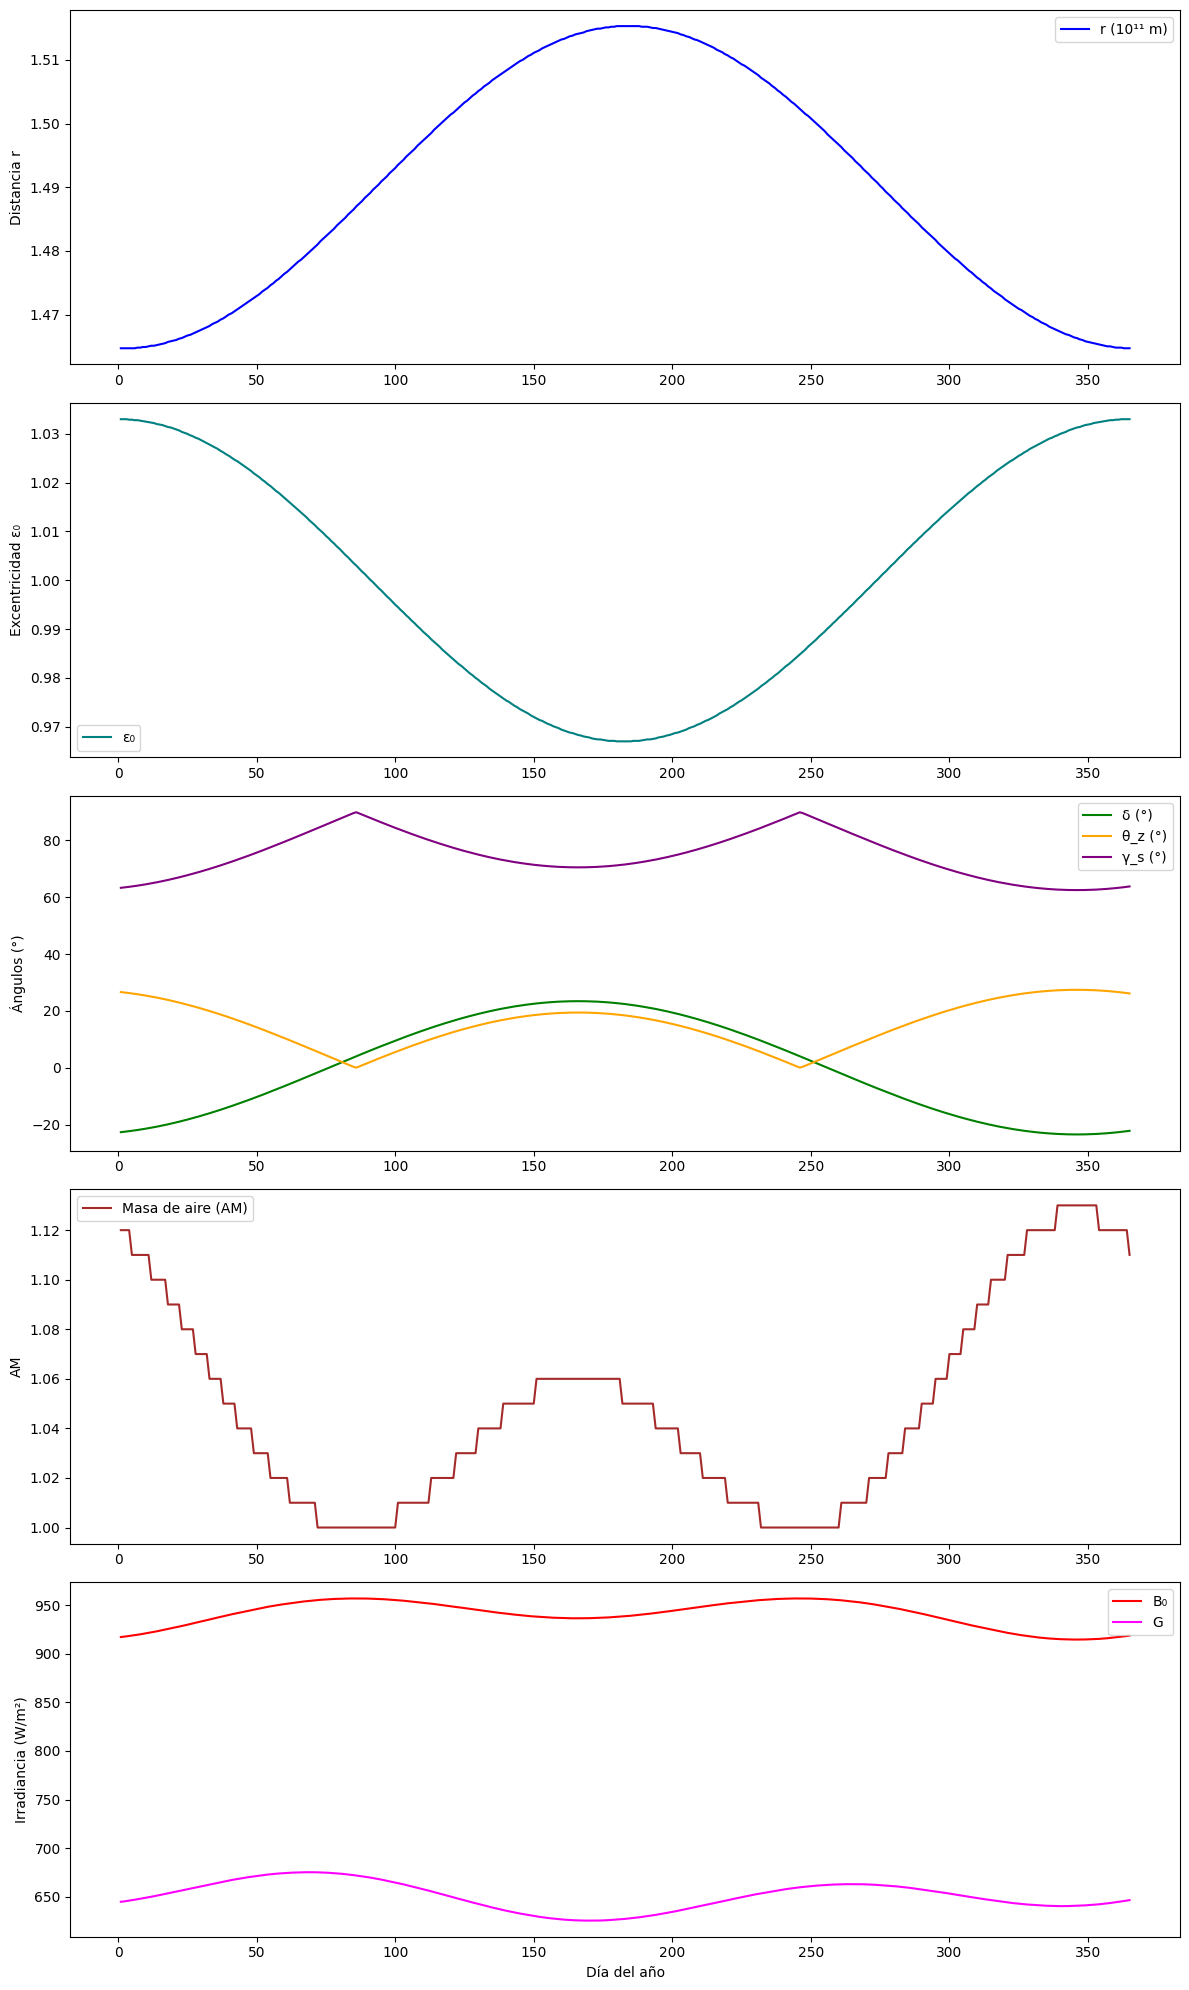

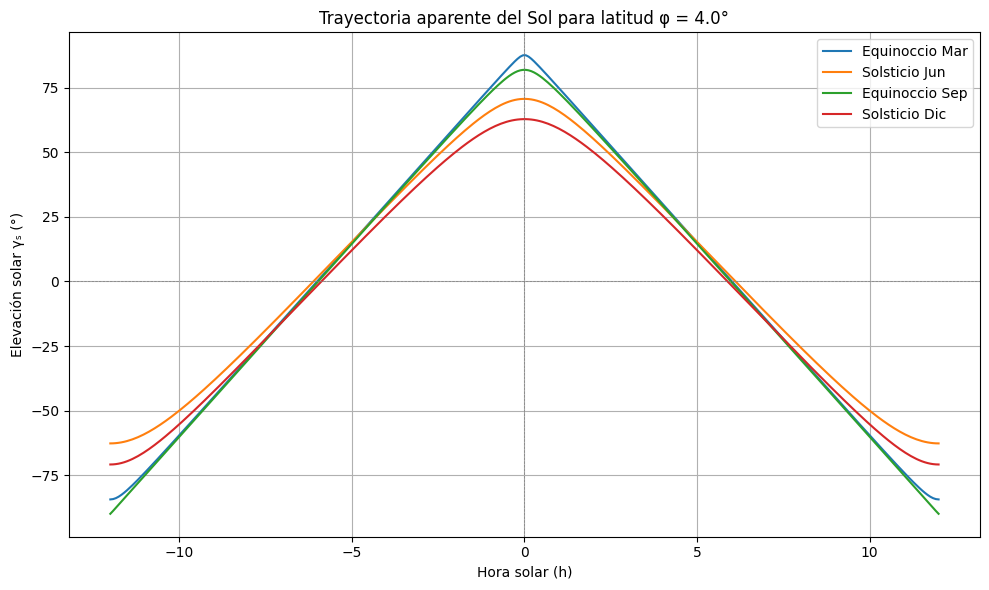

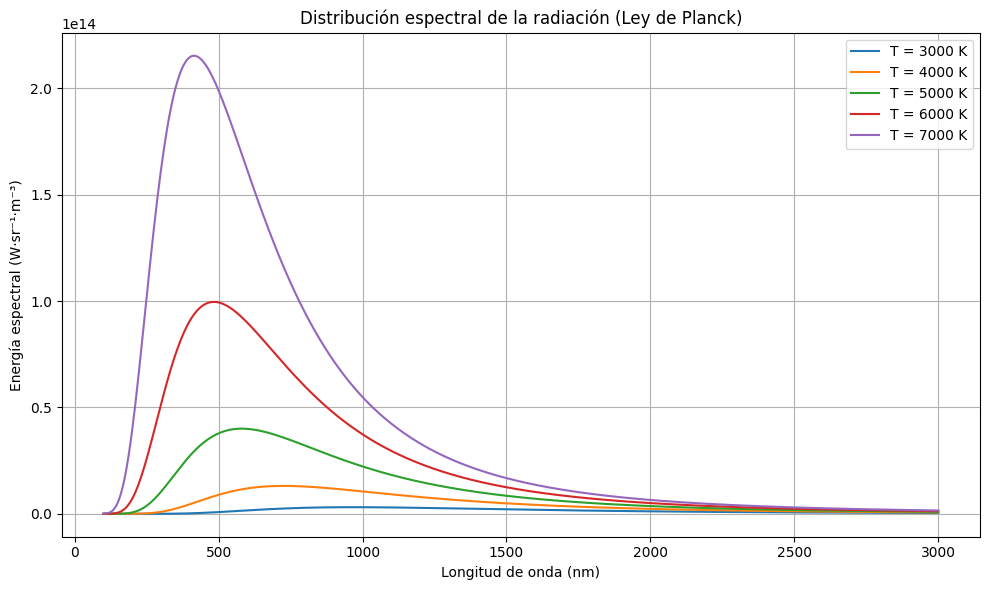

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DEL USUARIO ---
phi_deg = float(input("Ingresa la latitud en grados: "))


# --- PARTE 1: CÁLCULOS ANUALES ---

r_0 = 1.49e11  # Radio inicial usado.
phi = np.radians(phi_deg)  #Latitud, la convierto en radianes a su vez
S = 1367  # Constante solar (W/m²)
d_n = np.arange(1, 366) # Dias a lo largo del año

r = r_0 * (1 + 0.017 * np.sin(np.radians(360 * (d_n - 93) / 365))) # Primera ecuacion para hallar el radio a largo del año.
epsilon_0 = 1 + 0.033 * np.cos(2 * np.pi * d_n / 365) # Lo mismo pero en este caso es para poder determinar la excentricidad
delta = np.radians(23.45 * np.sin(np.radians(d_n + 284))) # En este caso es para determinar la declinacion

omega = np.zeros_like(d_n)  # mediodía solar
# Respectivas ecuaciones usadas en clase
cos_theta_z = np.sin(delta) * np.sin(phi) + np.cos(delta) * np.cos(phi) * np.cos(omega)
theta_z = np.arccos(cos_theta_z)
AM = 1 / np.maximum(np.cos(theta_z), 0.01)
B_0 = S * 0.7 ** AM
G = B_0 * epsilon_0 * 0.7 ** (AM ** 0.678)
gamma_s = np.arcsin(cos_theta_z)

data = pd.DataFrame({
    'Día': d_n,
    'r (10¹¹ m)': np.round(r / 1e11, 4),
    'ε₀': np.round(epsilon_0, 4),
    'δ (°)': np.round(np.degrees(delta), 2),
    'θ_z (°)': np.round(np.degrees(theta_z), 2),
    'AM': np.round(AM, 2),
    'B₀ (W/m²)': np.round(B_0, 1),
    'G (W/m²)': np.round(G, 1),
    'γ_s (°)': np.round(np.degrees(gamma_s), 2)
})

pd.set_option('display.max_rows', None)
print(data.to_string(index=False))

# Gráficas anuales
plt.figure(figsize=(12, 20))

plt.subplot(5, 1, 1)
plt.plot(d_n, data['r (10¹¹ m)'], label='r (10¹¹ m)', color='blue')
plt.ylabel('Distancia r')
plt.legend()

plt.subplot(5, 1, 2)
plt.plot(d_n, data['ε₀'], label='ε₀', color='teal')
plt.ylabel('Excentricidad ε₀')
plt.legend()

plt.subplot(5, 1, 3)
plt.plot(d_n, data['δ (°)'], label='δ (°)', color='green')
plt.plot(d_n, data['θ_z (°)'], label='θ_z (°)', color='orange')
plt.plot(d_n, data['γ_s (°)'], label='γ_s (°)', color='purple')
plt.ylabel('Ángulos (°)')
plt.legend()

plt.subplot(5, 1, 4)
plt.plot(d_n, data['AM'], label='Masa de aire (AM)', color='brown')
plt.ylabel('AM')
plt.legend()

plt.subplot(5, 1, 5)
plt.plot(d_n, data['B₀ (W/m²)'], label='B₀', color='red')
plt.plot(d_n, data['G (W/m²)'], label='G', color='magenta')
plt.ylabel('Irradiancia (W/m²)')
plt.xlabel('Día del año')
plt.legend()


plt.tight_layout()
plt.show()

# --- PARTE 2: TRAYECTORIA SOLAR EN DÍAS CLAVE ---

dias_clave = {
    "Equinoccio Mar": 80,
    "Solsticio Jun": 172,
    "Equinoccio Sep": 266,
    "Solsticio Dic": 355
}

omega_vals = np.radians(np.linspace(-180, 180, 300))
plt.figure(figsize=(10, 6))

for nombre, dia in dias_clave.items():
    delta_dia = np.radians(23.45 * np.sin(np.radians(dia + 284)))
    gamma_s = np.arcsin(np.sin(delta_dia) * np.sin(phi) + np.cos(delta_dia) * np.cos(phi) * np.cos(omega_vals))
    gamma_s_deg = np.degrees(gamma_s)
    horas = np.linspace(-12, 12, len(omega_vals))
    plt.plot(horas, gamma_s_deg, label=nombre)

plt.title(f'Trayectoria aparente del Sol para latitud φ = {phi_deg}°')
plt.xlabel('Hora solar (h)')
plt.ylabel('Elevación solar γₛ (°)')
plt.axhline(0, color='gray', linestyle='--', lw=0.5)
plt.axvline(0, color='gray', linestyle='--', lw=0.5)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# --- PARTE 3: LEY DE RADIACIÓN DE PLANCK ---

# Constantes físicas
h = 6.626e-34  # J·s
c = 3e8        # m/s
k = 1.38e-23   # J/K

# Longitud de onda
lambda_nm = np.linspace(100, 3000, 500)
lambda_m = lambda_nm * 1e-9

# Temperaturas en K
T_list = [3000, 4000, 5000, 6000, 7000]


def planck(wavelength, T):
    numerator = 2 * np.pi * h * c**2
    denominator = (wavelength**5) * (np.exp((h * c) / (wavelength * k * T)) - 1)
    return numerator / denominator  # W·sr⁻¹·m⁻³

# Gráfica de distribución espectral
plt.figure(figsize=(10, 6))
for T in T_list:
    E_lambda = planck(lambda_m, T)
    plt.plot(lambda_nm, E_lambda, label=f"T = {T} K")

plt.title('Distribución espectral de la radiación (Ley de Planck)')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Energía espectral (W·sr⁻¹·m⁻³)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

¿Desea hacer un cálculo para una hora específica (h), un día específico (d) o para todo el año (a)? (h/d/a): a
Por favor introduzca el año: 2025
Por favor introduzca el valor de la latitud (en grados [-90 a 90]): 4
Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): 4
Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): 0

Calculando parámetros para el año 2025:
------------------------------------------------------------------------------------
Día | Excentricidad | Radio (10^6 km) | Declinación (°) | G_mediodia (W/m²) | G_diaria_total (kWh/m²)
----|---------------|-----------------|-----------------|-------------------|-----------------------
  1 |        1.0330 |         147.057 |          -23.01 |            941.11 |                 6.490
  2 |        1.0330 |         147.057 |          -22.93 |            941.84 |                 6.496
  3 |        1.0330 

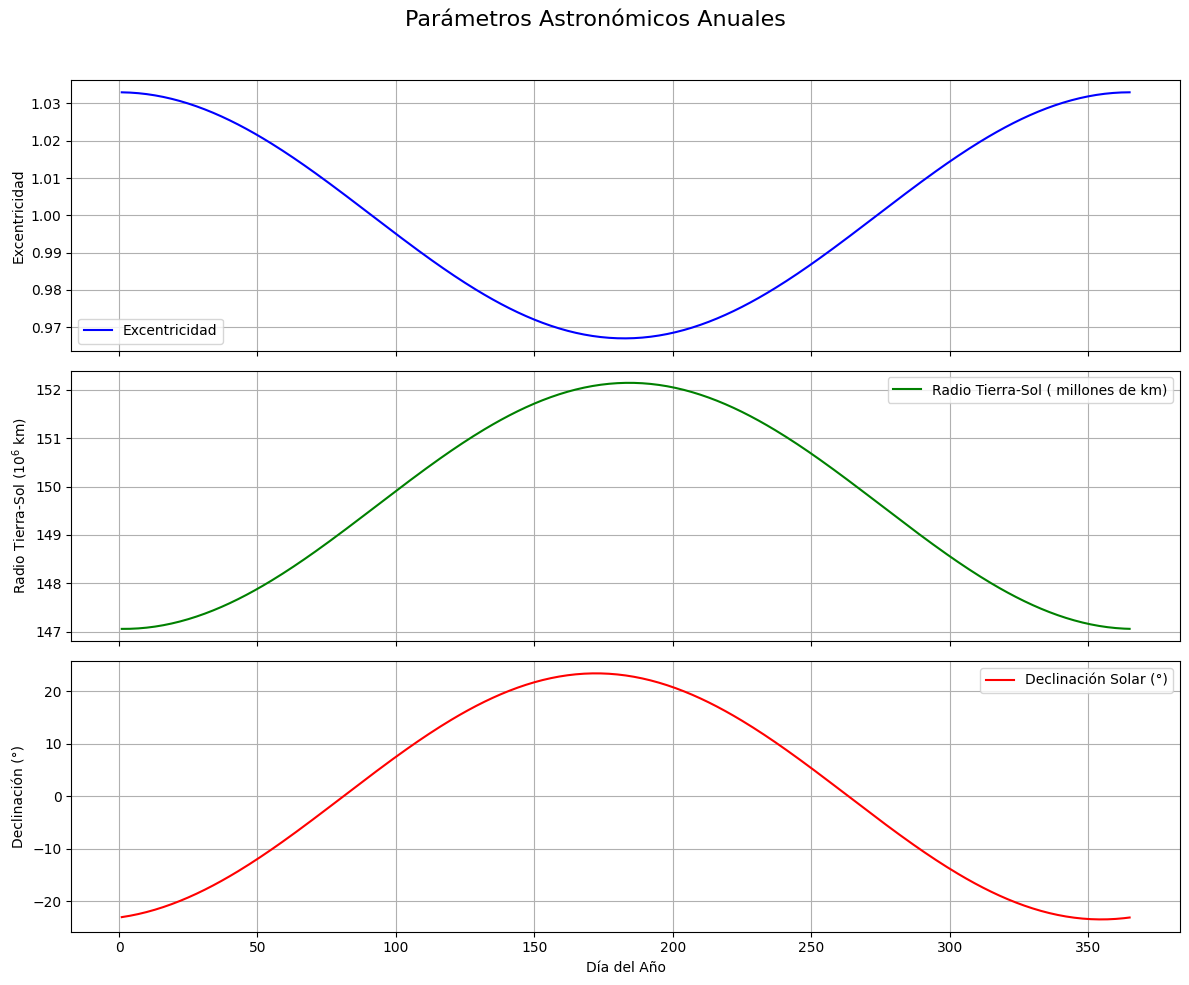

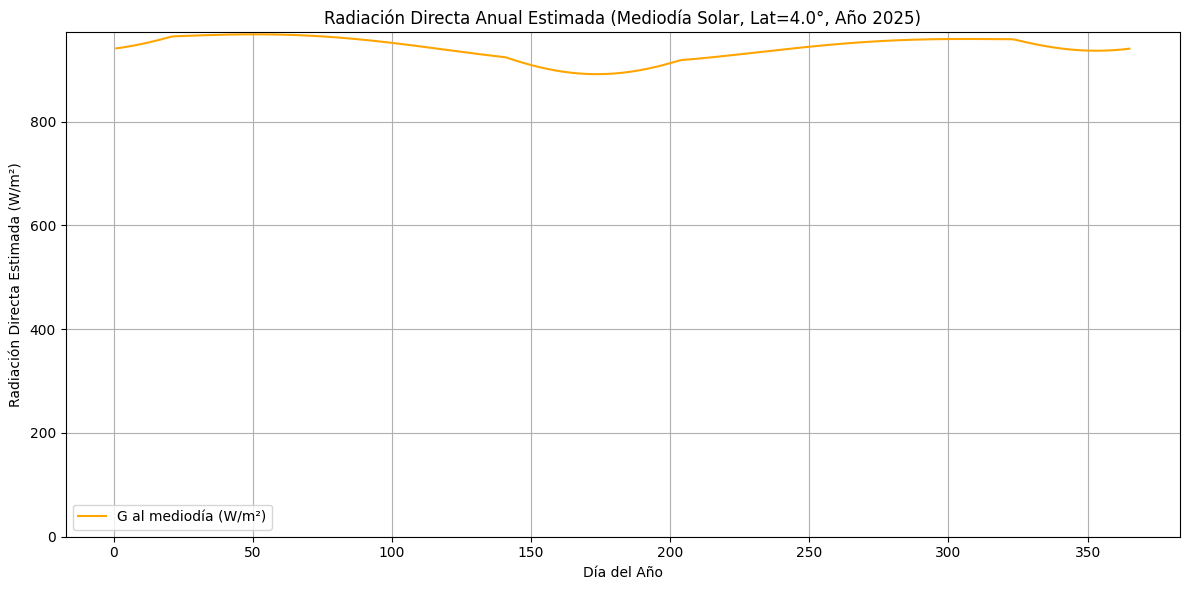


--- Resumen de Radiación al Mediodía Solar ---
Día con mayor radiación al mediodía: DN 51 (20 de February) con 968.15 W/m²
Día con menor radiación al mediodía: DN 174 (23 de June) con 891.38 W/m²
Mes con mayor radiación al mediodía: February (967.65 W/m² promedio)
Mes con menor radiación al mediodía: June (895.43 W/m² promedio)

--- Resumen de Radiación Diaria Total ---
Día con mayor radiación diaria total: DN 74 (15 de March) con 7.041 kWh/m²
Día con menor radiación diaria total: DN 174 (23 de June) con 6.237 kWh/m²
Mes con mayor radiación diaria total: March (7.027 kWh/m² promedio)
Mes con menor radiación diaria total: June (6.265 kWh/m² promedio)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import calendar # Importar el módulo calendar para obtener el nombre de los meses

# Definiendo las constantes.
Bo = 1367 # W/m^2
ro = 1.496e11 # Radio Tierra-Sol medio (m)

def es_año_bisiesto(año):
    if año % 4 == 0:
        if año % 100 == 0:
            return año % 400 == 0
        else:
            return True
    else:
        return False

def dia_del_año(dia, mes, año):
    dias_por_mes = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    if es_año_bisiesto(año):
        dias_por_mes[2] = 29

    if not (1 <= mes <= 12 and 1 <= dia <= dias_por_mes[mes]):
        return f"Fecha Inválida: Día {dia} o Mes {mes} fuera de rango para el año {año}."

    numero_dia = sum(dias_por_mes[:mes]) + dia
    return numero_dia

# --- Nueva función para convertir DN a Día/Mes
def dn_a_fecha(dn, año):
    dias_por_mes = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    if es_año_bisiesto(año):
        dias_por_mes[2] = 29

    mes = 1
    while dn > dias_por_mes[mes]:
        dn -= dias_por_mes[mes]
        mes += 1
    dia = dn
    return dia, mes

# --- Funciones de Cálculo Solar ---
def calcular_excentricidad(dn_final):

    angulo_en_radianes = np.radians((360 * dn_final) / 365)
    return 1 + 0.033 * np.cos(angulo_en_radianes)

def calcular_radio_tierra_sol(dn_final):

    angulo_en_radianes2 = np.radians((360 * (dn_final - 93)) / 365)

    return ro * (1 + 0.017 * np.sin(angulo_en_radianes2))


def calcular_declinacion(dn_final):

    return 23.45 * np.sin(np.radians((360 / 365) * (dn_final - 81)))

def calcular_parametros_hora_especifica(dn_final, H_local, phi_grados, beta_grados, azimut_superficie_grados, declinacion_grados_precal=None, excentricidad_precal=None):

    if declinacion_grados_precal is None:
        declinacion_grados = calcular_declinacion(dn_final)
    else:
        declinacion_grados = declinacion_grados_precal

    if excentricidad_precal is None:
        excentricidad = calcular_excentricidad(dn_final)
    else:
        excentricidad = excentricidad_precal

    w_grados = 15 * (H_local - 12)

    phi_rad = np.radians(phi_grados)
    beta_rad = np.radians(beta_grados)
    azimut_superficie_rad = np.radians(azimut_superficie_grados)
    declinacion_rad = np.radians(declinacion_grados)
    w_rad = np.radians(w_grados)

    cos_theta_s = (
        np.sin(declinacion_rad) * np.sin(phi_rad) * np.cos(beta_rad)
        - np.sign(phi_grados) * np.sin(declinacion_rad) * np.cos(phi_rad) * np.sin(beta_rad) * np.cos(azimut_superficie_rad)
        + np.cos(declinacion_rad) * np.cos(phi_rad) * np.cos(beta_rad) * np.cos(w_rad)
        + np.sign(phi_grados) * np.cos(declinacion_rad) * np.sin(beta_rad) * np.cos(azimut_superficie_rad) * np.cos(w_rad)
        + np.cos(declinacion_rad) * np.sin(w_rad) * np.sin(beta_rad)
    )
    cos_theta_s = np.clip(cos_theta_s, -1.0, 1.0)


    cos_theta_zs = (
        np.sin(declinacion_rad) * np.sin(phi_rad)
        + np.cos(declinacion_rad) * np.cos(phi_rad) * np.cos(w_rad)
    )
    cos_theta_zs = np.clip(cos_theta_zs, -1.0, 1.0)

    am = None
    g = 0.0

    if cos_theta_zs > 1e-6:
        am = 1 / cos_theta_zs

        am = min(am, 38)

        if cos_theta_s > 1e-6:
            transmitancia_directa = 0.7**(am**0.678)
            g = Bo * excentricidad * transmitancia_directa * cos_theta_s
            g = max(0, g)
        else:
            g = 0.0
    else:
        g = 0.0


    return w_grados, cos_theta_s, cos_theta_zs, am, g

# --- Nueva función para calcular la radiación diaria total ---
def calcular_radiacion_diaria_total(dn_final, phi_grados, beta_grados, azimut_superficie_grados):
    horas_decimales_dia = np.arange(0, 24, 2/60) # Cada 2 minutos
    G_diaria_valores = []

    exc_dia = calcular_excentricidad(dn_final)
    dec_dia = calcular_declinacion(dn_final)

    for H_actual in horas_decimales_dia:
        _, _, _, _, g = calcular_parametros_hora_especifica(dn_final, H_actual, phi_grados, beta_grados, azimut_superficie_grados, dec_dia, exc_dia)
        G_diaria_valores.append(g if g is not None else 0)

    # La radiación es en W/m^2, la integramos sobre el tiempo para obtener energía (J/m^2 o Wh/m^2)
    # Convertimos a Wh/m^2 multiplicando por el intervalo de tiempo en horas (2/60 horas)
    # y dividiendo por 1000 para kWh/m^2
    radiacion_diaria_kwh_m2 = np.sum(G_diaria_valores) * (2/60) / 1000
    return radiacion_diaria_kwh_m2


# --- Funciones de Graficación ---
def graficar_anual_fijos(dias_año_num, excentricidades, radios_km, declinaciones, titulo_base=""):
    fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"{titulo_base}Parámetros Astronómicos Anuales", fontsize=16)

    axs[0].plot(dias_año_num, excentricidades, label='Excentricidad', color='blue')
    axs[0].set_ylabel('Excentricidad')
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(dias_año_num, radios_km, label='Radio Tierra-Sol ( millones de km)', color='green')
    axs[1].set_ylabel('Radio Tierra-Sol (10$^6$ km)')
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(dias_año_num, declinaciones, label='Declinación Solar (°)', color='red')
    axs[2].set_ylabel('Declinación (°)')
    axs[2].set_xlabel('Día del Año')
    axs[2].grid(True)
    axs[2].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def graficar_radiacion_global_anual(dias_año_num, G_anual, titulo="Radiación Directa Anual Estimada (Mediodía Solar)"):
    plt.figure(figsize=(12, 6))

    valid_indices = ~np.isnan(G_anual)
    if np.any(valid_indices):
        plt.plot(dias_año_num[valid_indices], G_anual[valid_indices], label='G al mediodía (W/m²)', color='orange')
    else:
        plt.plot([],[], label='G al mediodía (W/m²)', color='orange')

    plt.title(titulo)
    plt.xlabel('Día del Año')
    plt.ylabel('Radiación Directa Estimada (W/m²)')
    plt.legend()
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()

def graficar_radiacion_global_diaria(horas_dia, G_diaria, titulo="Radiación Directa Diaria Estimada"):
    plt.figure(figsize=(12, 7))
    G_diaria_np = np.array(G_diaria)
    horas_dia_np = np.array(horas_dia)


    plt.plot(horas_dia_np, G_diaria_np, label='G (W/m²)', color='purple')

    plt.title(titulo)
    plt.xlabel('Hora Local (decimal)')
    plt.ylabel('Radiación Directa Estimada (W/m²)')
    plt.xticks(np.arange(0, 25, 2))
    plt.legend()
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.xlim(0, 24)
    plt.tight_layout()
    plt.show()


def main():
    tipo_calculo = input("¿Desea hacer un cálculo para una hora específica (h), un día específico (d) o para todo el año (a)? (h/d/a): ").lower()

    if tipo_calculo not in ['h', 'd', 'a']:
        print("Tipo de cálculo no válido. Seleccione 'h', 'd' o 'a'.")
        return


    if tipo_calculo == 'a':
        año = int(input("Por favor introduzca el año: "))
        phi_grados = float(input("Por favor introduzca el valor de la latitud (en grados [-90 a 90]): "))
        beta_grados = float(input("Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): "))
        azimut_superficie_grados = float(input("Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): "))
    elif tipo_calculo == 'd':
        fecha_str = input("Por favor introduce la fecha (DD MM): ")
        año = int(input("Por favor introduzca el año: "))
        try:
            dia_n, mes_n = fecha_str.split()
            dia = int(dia_n)
            mes = int(mes_n)
        except ValueError:
            print("Formato de fecha incorrecto. Use DD MM.")
            return
        dn_final = dia_del_año(dia, mes, año)
        if isinstance(dn_final, str):
            print(dn_final)
            return

        phi_grados = float(input("Por favor introduzca el valor de la latitud (en grados [-90 a 90]): "))
        beta_grados = float(input("Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): "))
        azimut_superficie_grados = float(input("Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): "))

    elif tipo_calculo == 'h':
        fecha_str = input("Por favor introduce la fecha (DD MM): ")
        año = int(input("Por favor introduzca el año: "))
        try:
            dia_n, mes_n = fecha_str.split()
            dia = int(dia_n)
            mes = int(mes_n)
        except ValueError:
            print("Formato de fecha incorrecto. Use DD MM.")
            return
        dn_final = dia_del_año(dia, mes, año)
        if isinstance(dn_final, str):
            print(dn_final)
            return

        phi_grados = float(input("Por favor introduzca el valor de la latitud (en grados [-90 a 90]): "))
        beta_grados = float(input("Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): "))
        azimut_superficie_grados = float(input("Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): "))
        H_local = float(input("Por favor introduzca el valor de la hora local (en horas decimales, e.g., 13.5 para 1:30 PM): "))



    if tipo_calculo == 'a':
        num_dias_año = 366 if es_año_bisiesto(año) else 365
        dias_año_indices = np.arange(1, num_dias_año + 1)

        excentricidades_anuales = []
        radios_anuales_km = []
        declinaciones_anuales = []
        G_mediodia_anual = []
        G_diaria_total_anual = [] # Lista para almacenar la radiación diaria total

        print(f"\nCalculando parámetros para el año {año}:")
        print("------------------------------------------------------------------------------------")
        print("Día | Excentricidad | Radio (10^6 km) | Declinación (°) | G_mediodia (W/m²) | G_diaria_total (kWh/m²)")
        print("----|---------------|-----------------|-----------------|-------------------|-----------------------")

        for dn in dias_año_indices:
            exc = calcular_excentricidad(dn)
            rad_m = calcular_radio_tierra_sol(dn)
            dec = calcular_declinacion(dn)

            # Cálculo de la radiación al mediodía solar
            _, _, _, _, g_mediodia = calcular_parametros_hora_especifica(dn, 12.0, phi_grados, beta_grados, azimut_superficie_grados, dec, exc)

            # Cálculo de la radiación diaria total
            g_diaria_total = calcular_radiacion_diaria_total(dn, phi_grados, beta_grados, azimut_superficie_grados)

            excentricidades_anuales.append(exc)
            radios_anuales_km.append(rad_m / 1e9)
            declinaciones_anuales.append(dec)
            G_mediodia_anual.append(g_mediodia if g_mediodia is not None else np.nan)
            G_diaria_total_anual.append(g_diaria_total) # Añadir a la lista


            print(f"{dn:3d} | {exc:13.4f} | {rad_m/1e9:15.3f} | {dec:15.2f} | {(f'{g_mediodia:.2f}' if g_mediodia is not None else 'N/A'):>17} | {g_diaria_total:21.3f}")
        print("------------------------------------------------------------------------------------")

        graficar_anual_fijos(dias_año_indices, excentricidades_anuales, radios_anuales_km, declinaciones_anuales)
        graficar_radiacion_global_anual(dias_año_indices, np.array(G_mediodia_anual),
                                         titulo=f"Radiación Directa Anual Estimada (Mediodía Solar, Lat={phi_grados}°, Año {año})")

        # --- Análisis de radiación anual (mediodía) ---
        if np.any(~np.isnan(G_mediodia_anual)):
            max_g_mediodia = np.nanmax(G_mediodia_anual)
            min_g_mediodia = np.nanmin(G_mediodia_anual)

            idx_max_g_mediodia_dn = np.where(G_mediodia_anual == max_g_mediodia)[0][0] + 1
            idx_min_g_mediodia_dn = np.where(G_mediodia_anual == min_g_mediodia)[0][0] + 1

            dia_max_mediodia, mes_max_mediodia = dn_a_fecha(idx_max_g_mediodia_dn, año)
            dia_min_mediodia, mes_min_mediodia = dn_a_fecha(idx_min_g_mediodia_dn, año)


            print("\n--- Resumen de Radiación al Mediodía Solar ---")
            print(f"Día con mayor radiación al mediodía: DN {idx_max_g_mediodia_dn} ({dia_max_mediodia} de {calendar.month_name[mes_max_mediodia]}) con {max_g_mediodia:.2f} W/m²")
            print(f"Día con menor radiación al mediodía: DN {idx_min_g_mediodia_dn} ({dia_min_mediodia} de {calendar.month_name[mes_min_mediodia]}) con {min_g_mediodia:.2f} W/m²")

            # Calcular radiación promedio mensual al mediodía
            radiacion_mensual_mediodia = {}
            dias_por_mes_anual = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
            if es_año_bisiesto(año):
                dias_por_mes_anual[2] = 29

            current_day_index = 0
            for i in range(1, 13):
                month_days = dias_por_mes_anual[i]
                # Asegurarse de que el slicing no se extienda más allá del final de la lista G_mediodia_anual
                monthly_radiation = [G_mediodia_anual[current_day_index + j] for j in range(month_days) if (current_day_index + j < len(G_mediodia_anual)) and not np.isnan(G_mediodia_anual[current_day_index + j])]
                if monthly_radiation:
                    radiacion_mensual_mediodia[i] = np.mean(monthly_radiation)
                else:
                    radiacion_mensual_mediodia[i] = np.nan
                current_day_index += month_days

            if radiacion_mensual_mediodia:
                # Filtrar meses con NaN antes de buscar max/min
                valid_months_mediodia = {m: r for m, r in radiacion_mensual_mediodia.items() if not np.isnan(r)}
                if valid_months_mediodia:
                    max_mes_mediodia = max(valid_months_mediodia, key=valid_months_mediodia.get)
                    min_mes_mediodia = min(valid_months_mediodia, key=valid_months_mediodia.get)

                    print(f"Mes con mayor radiación al mediodía: {calendar.month_name[max_mes_mediodia]} ({radiacion_mensual_mediodia[max_mes_mediodia]:.2f} W/m² promedio)")
                    print(f"Mes con menor radiación al mediodía: {calendar.month_name[min_mes_mediodia]} ({radiacion_mensual_mediodia[min_mes_mediodia]:.2f} W/m² promedio)")
                else:
                    print("No hay datos válidos para calcular la radiación promedio mensual al mediodía.")


        # --- Análisis de radiación diaria total anual ---
        if np.any(~np.isnan(G_diaria_total_anual)):
            max_g_diaria_total = np.nanmax(G_diaria_total_anual)
            min_g_diaria_total = np.nanmin(G_diaria_total_anual)

            idx_max_g_diaria_total_dn = np.where(G_diaria_total_anual == max_g_diaria_total)[0][0] + 1
            idx_min_g_diaria_total_dn = np.where(G_diaria_total_anual == min_g_diaria_total)[0][0] + 1

            dia_max_diaria_total, mes_max_diaria_total = dn_a_fecha(idx_max_g_diaria_total_dn, año)
            dia_min_diaria_total, mes_min_diaria_total = dn_a_fecha(idx_min_g_diaria_total_dn, año)


            print("\n--- Resumen de Radiación Diaria Total ---")
            print(f"Día con mayor radiación diaria total: DN {idx_max_g_diaria_total_dn} ({dia_max_diaria_total} de {calendar.month_name[mes_max_diaria_total]}) con {max_g_diaria_total:.3f} kWh/m²")
            print(f"Día con menor radiación diaria total: DN {idx_min_g_diaria_total_dn} ({dia_min_diaria_total} de {calendar.month_name[mes_min_diaria_total]}) con {min_g_diaria_total:.3f} kWh/m²")

            # Calcular radiación promedio mensual diaria total
            radiacion_mensual_diaria_total = {}
            current_day_index = 0
            for i in range(1, 13):
                month_days = dias_por_mes_anual[i]
                # Asegurarse de que el slicing no se extienda más allá del final de la lista G_diaria_total_anual
                monthly_radiation = [G_diaria_total_anual[current_day_index + j] for j in range(month_days) if (current_day_index + j < len(G_diaria_total_anual)) and not np.isnan(G_diaria_total_anual[current_day_index + j])]
                if monthly_radiation:
                    radiacion_mensual_diaria_total[i] = np.mean(monthly_radiation)
                else:
                    radiacion_mensual_diaria_total[i] = np.nan
                current_day_index += month_days

            if radiacion_mensual_diaria_total:
                # Filtrar meses con NaN antes de buscar max/min
                valid_months_diaria_total = {m: r for m, r in radiacion_mensual_diaria_total.items() if not np.isnan(r)}
                if valid_months_diaria_total:
                    max_mes_diaria_total = max(valid_months_diaria_total, key=valid_months_diaria_total.get)
                    min_mes_diaria_total = min(valid_months_diaria_total, key=valid_months_diaria_total.get)

                    print(f"Mes con mayor radiación diaria total: {calendar.month_name[max_mes_diaria_total]} ({radiacion_mensual_diaria_total[max_mes_diaria_total]:.3f} kWh/m² promedio)")
                    print(f"Mes con menor radiación diaria total: {calendar.month_name[min_mes_diaria_total]} ({radiacion_mensual_diaria_total[min_mes_diaria_total]:.3f} kWh/m² promedio)")
                else:
                    print("No hay datos válidos para calcular la radiación promedio mensual diaria total.")


    elif tipo_calculo == 'd':
        print(f"\nCalculando para el día {dia}/{mes}/{año} (Día del año: {dn_final}):")
        print(f"Latitud: {phi_grados}°, Inclinación: {beta_grados}°, Azimut Superficie: {azimut_superficie_grados}°")
        print("--------------------------------------------------------------------------")
        print("Hora    | w (°) | cos(θs) | cos(θzs) |   AM   | G (W/m²)")
        print("--------|-------|---------|----------|--------|----------")

        horas_decimales_dia = np.arange(0, 24, 2/60) # Cada 2 minutos
        G_diaria = []

        exc_dia = calcular_excentricidad(dn_final)
        dec_dia = calcular_declinacion(dn_final)
        print(f"Excentricidad del día: {exc_dia:.4f}, Declinación del día: {dec_dia:.2f}°\n")

        for H_actual in horas_decimales_dia:
            w_grados, cos_theta_s, cos_theta_zs, am, g = \
                calcular_parametros_hora_especifica(dn_final, H_actual, phi_grados, beta_grados, azimut_superficie_grados, dec_dia, exc_dia)

            hora_h = int(H_actual)
            min_m = int(round((H_actual * 60) % 60))
            hora_reloj_str = f"{hora_h:02d}:{min_m:02d}"

            G_diaria.append(g if g is not None else 0)

            am_str = f"{am:6.2f}" if am is not None else "   -   "
            g_str = f"{g:8.2f}" if g is not None else "    -   "
            print(f"{hora_reloj_str:8}| {w_grados:5.1f} | {cos_theta_s:7.3f} | {cos_theta_zs:8.3f} | {am_str} | {g_str}")
        print("--------------------------------------------------------------------------")

        radiacion_total_dia_kwh_m2 = calcular_radiacion_diaria_total(dn_final, phi_grados, beta_grados, azimut_superficie_grados)
        print(f"\nRadiación directa total para el día {dia}/{mes}/{año}: {radiacion_total_dia_kwh_m2:.3f} kWh/m²")

        graficar_radiacion_global_diaria(horas_decimales_dia, G_diaria,
                                          titulo=f"Radiación Directa Estimada - {dia}/{mes}/{año} (Lat={phi_grados}°)")


        print("\nGenerando gráfica de radiación anual (mediodía) para contexto...")
        num_dias_año_actual = 366 if es_año_bisiesto(año) else 365
        dias_año_actual_indices = np.arange(1, num_dias_año_actual + 1)
        G_mediodia_contexto_anual = []
        for dn_temp in dias_año_actual_indices:
            exc_temp = calcular_excentricidad(dn_temp)
            dec_temp = calcular_declinacion(dn_temp)
            _, _, _, _, g_temp = calcular_parametros_hora_especifica(dn_temp, 12.0, phi_grados, beta_grados, azimut_superficie_grados, dec_temp, exc_temp)
            G_mediodia_contexto_anual.append(g_temp if g_temp is not None else np.nan)

        graficar_radiacion_global_anual(dias_año_actual_indices, np.array(G_mediodia_contexto_anual),
                                         titulo=f"Contexto: Rad. Directa Anual Estimada (Mediodía, Lat={phi_grados}°, Año {año})")


    elif tipo_calculo == 'h':
        exc = calcular_excentricidad(dn_final)
        rad_m = calcular_radio_tierra_sol(dn_final)
        dec = calcular_declinacion(dn_final)

        w_grados, cos_theta_s, cos_theta_zs, am, g = \
            calcular_parametros_hora_especifica(dn_final, H_local, phi_grados, beta_grados, azimut_superficie_grados, dec, exc)

        print(f"\nResultados para {dia}/{mes}/{año} a las {H_local:.2f} horas (Día del año: {dn_final}):")
        print(f"Latitud: {phi_grados}°, Inclinación: {beta_grados}°, Azimut Sup.: {azimut_superficie_grados}°")
        print("----------------------------------------------------")
        print(f"Excentricidad:                  {exc:.5f}")
        print(f"Radio Tierra-Sol (10^6 km):     {rad_m/1e9:.3f}")
        print(f"Declinación Solar (grados):     {dec:.2f}")
        print(f"Ángulo Horario w (grados):      {w_grados:.2f}")
        print(f"Coseno Ángulo Incidencia (θs): {cos_theta_s:.4f}")
        print(f"Coseno Ángulo Cenital (θzs):    {cos_theta_zs:.4f}")
        if am is not None:
            print(f"Masa de Aire (AM):              {am:.2f}")
            print(f"Radiación Directa G (W/m²):     {g:.2f}")
        else:
            if cos_theta_zs <= 1e-6:
                print("El Sol está por debajo del horizonte. No se calcula AM ni Radiación.")
            else:
                 print("Masa de Aire y Radiación no calculables bajo las condiciones dadas (e.g. superficie no ve el sol).")
        print("----------------------------------------------------")

if __name__ == "__main__":
    main()

¿Desea hacer un cálculo para una hora específica (h), un día específico (d), para todo el año (a), o cálculo de paneles solares (p)? (h/d/a/p): p
Por favor introduzca el año: 2025
Por favor introduzca el valor de la latitud (en grados [-90 a 90]): 4
Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): 1
Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): 0

Calculando parámetros para el año 2025:
------------------------------------------------------------------------------------
Día | Excentricidad | Radio (10^6 km) | Declinación (°) | G_mediodia (W/m²) | G_diaria_total (kWh/m²)
----|---------------|-----------------|-----------------|-------------------|-----------------------
  1 |        1.0330 |         147.057 |          -23.01 |            877.25 |                 6.002
  2 |        1.0330 |         147.057 |          -22.93 |            878.01 |        

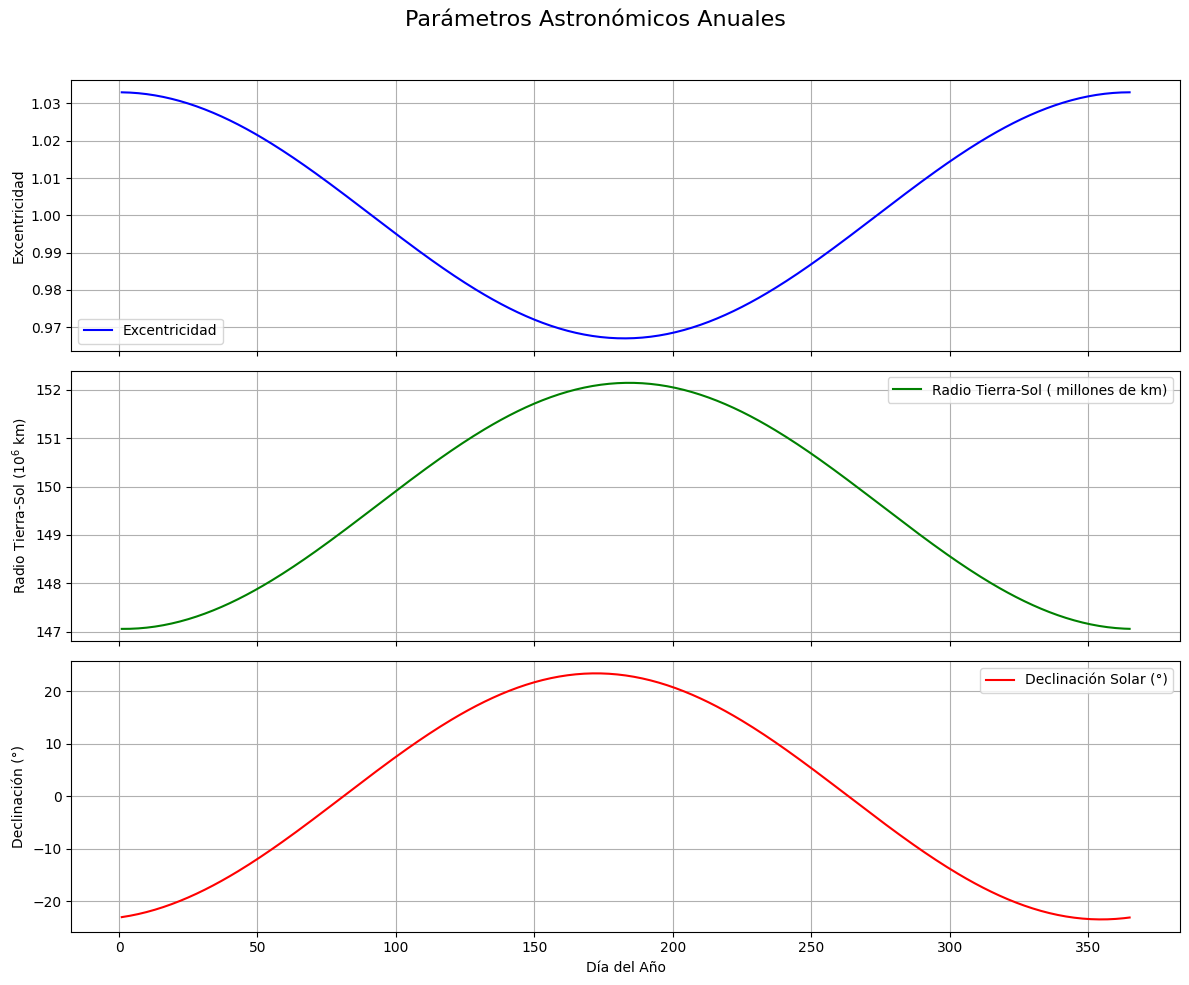

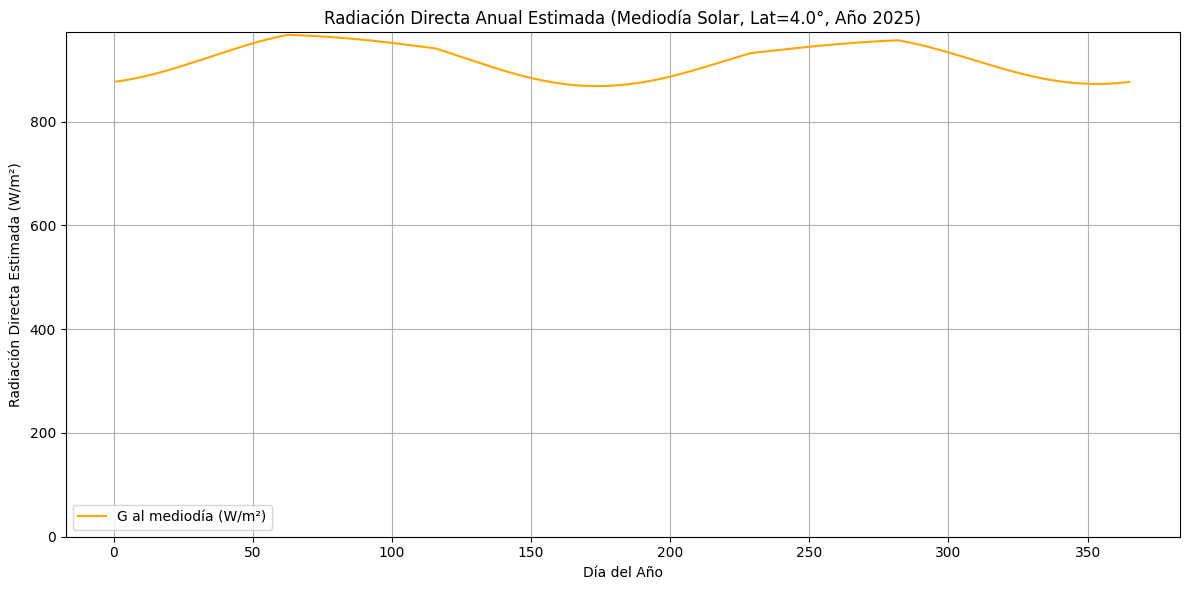


--- Resumen de Radiación al Mediodía Solar ---
Día con mayor radiación al mediodía: DN 63 (4 de March) con 967.16 W/m²
Día con menor radiación al mediodía: DN 174 (23 de June) con 868.50 W/m²
Mes con mayor radiación al mediodía: March (963.40 W/m² promedio)
Mes con menor radiación al mediodía: June (872.12 W/m² promedio)

--- Resumen de Radiación Diaria Total ---
Día con mayor radiación diaria total: DN 83 (24 de March) con 6.802 kWh/m²
Día con menor radiación diaria total: DN 353 (19 de December) con 5.967 kWh/m²


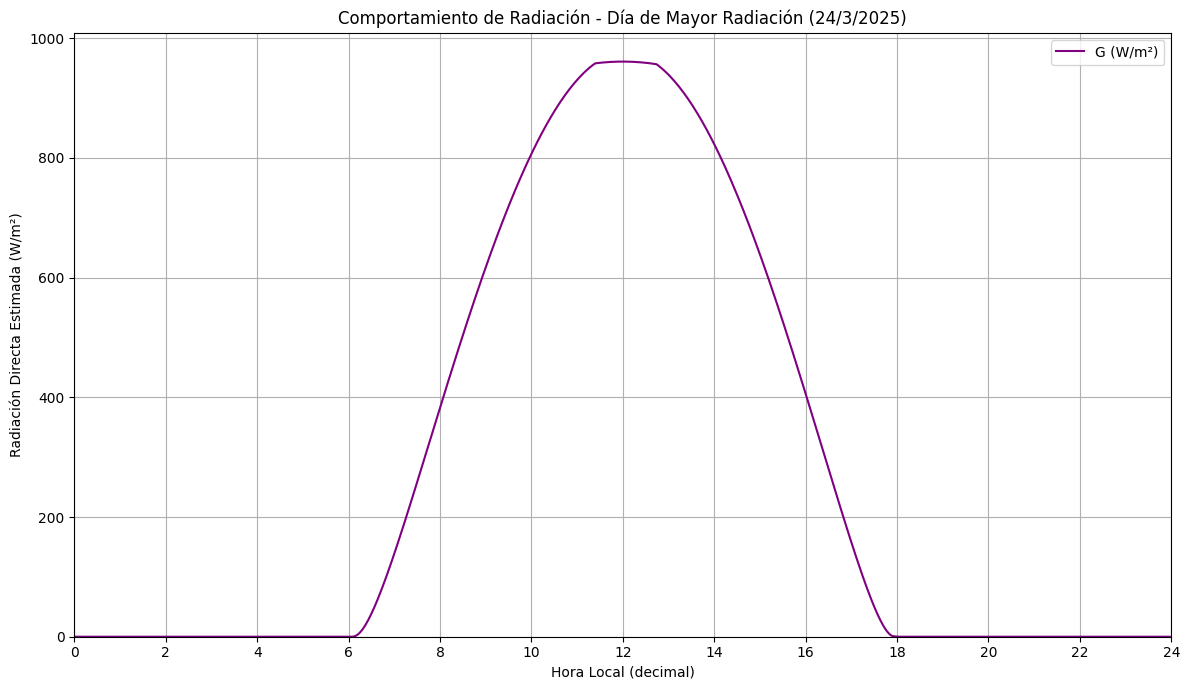


--- Análisis de Radiación para Día de Mayor Radiación (24/3/2025) ---
Ecuación de la curva (aproximada, y = ax^3 + bx^2 + cx + d):
   a = -0.086985
   b = -27.870029
   c = 710.704578
   d = -3429.502631
Integral de la función de radiación (0 a 24h): -13265.09 Wh/m²
Promedio de radiación diaria: -552.71 W/m²


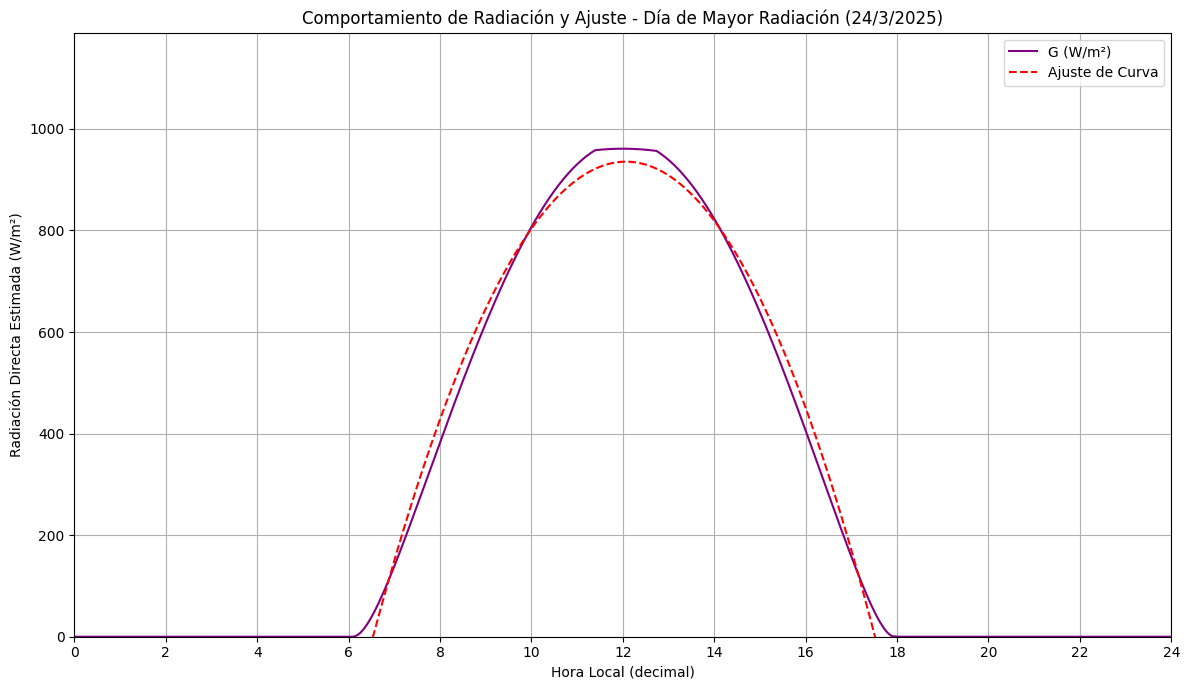

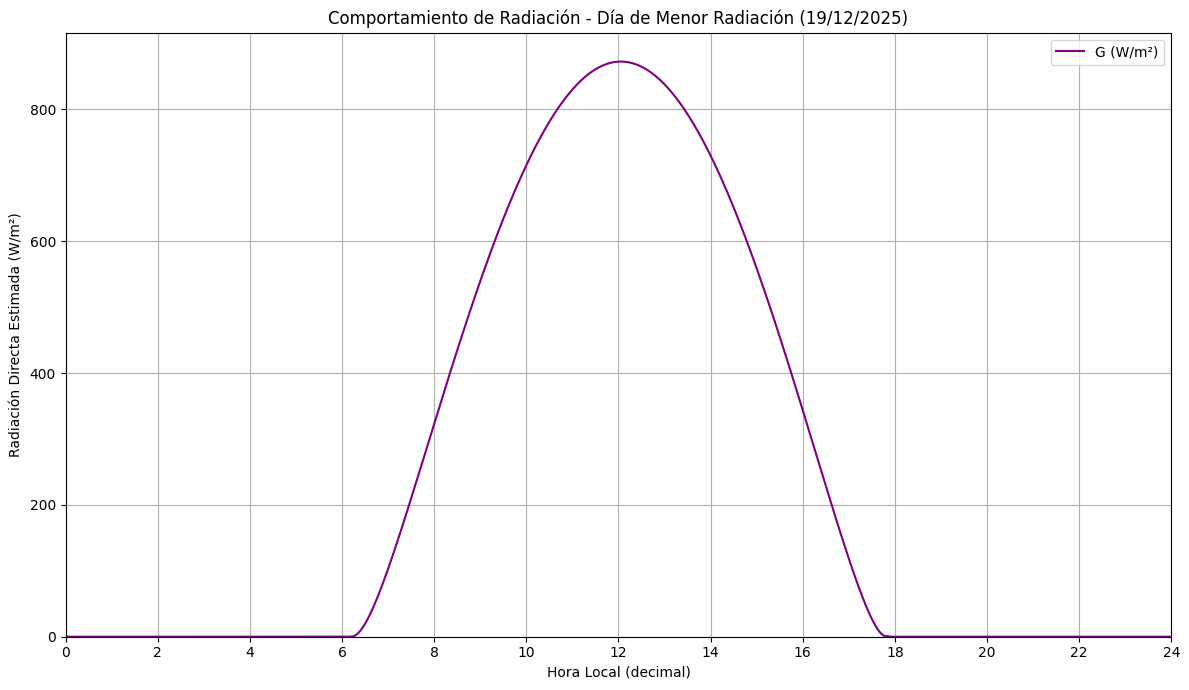


--- Análisis de Radiación para Día de Menor Radiación (19/12/2025) ---
Ecuación de la curva (aproximada, y = ax^3 + bx^2 + cx + d):
   a = -0.085342
   b = -25.848152
   c = 661.135183
   d = -3226.098669
Integral de la función de radiación (0 a 24h): -13206.35 Wh/m²
Promedio de radiación diaria: -550.26 W/m²


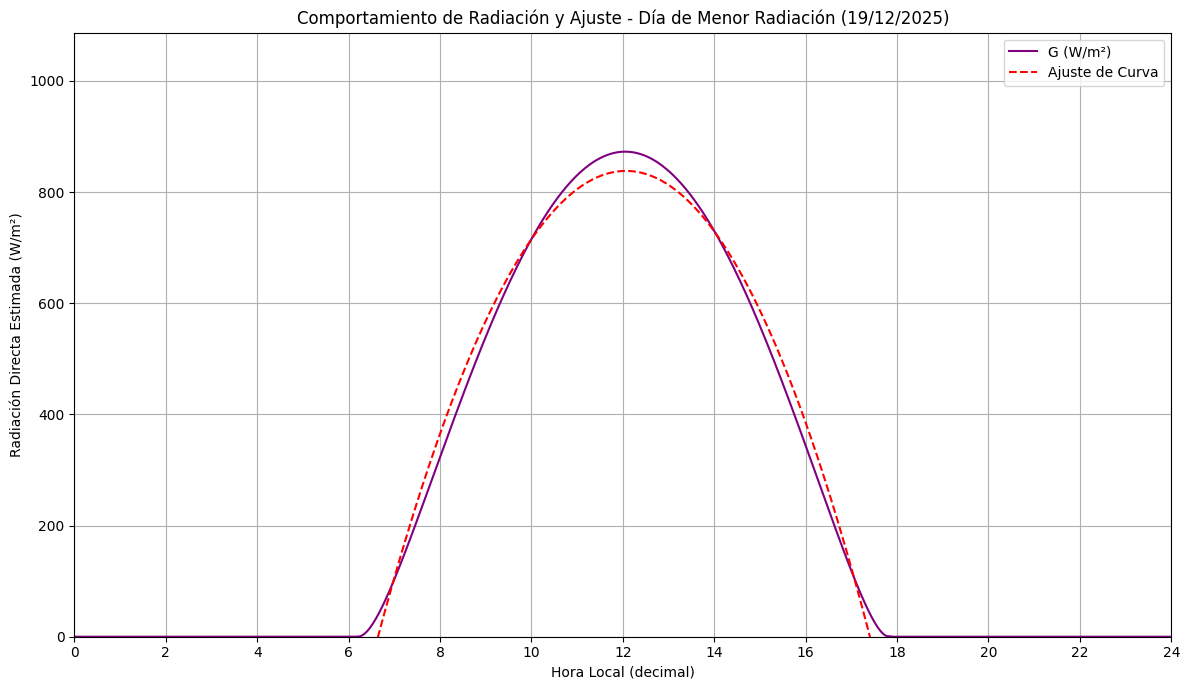

Mes con mayor radiación diaria total: March (6.773 kWh/m² promedio)
Mes con menor radiación diaria total: December (5.987 kWh/m² promedio)

--- Información del Panel Solar ---
Ingrese la potencia pico del panel solar (en W): 120
Ingrese el porcentaje de eficiencia del panel solar (ej. 20 para 20%): 80
Ingrese el área del panel solar (en m²): 1.2

Potencia de salida total por panel: 96.00 W
Potencia por área del panel: 80.00 W/m²

--- Información de Consumo Eléctrico ---
Ingrese el consumo de electricidad de su recibo del mes de mayor gasto (en kWh): 130
Ingrese el número del mes (1-12) en el que tuvo el mayor gasto: 2

Consumo diario promedio en el mes de mayor gasto (February): 4.64 kWh/día
Consumo diario objetivo (incluyendo 20% extra): 5.57 kWh/día
Energía generada por un panel al día (basado en el día de menor radiación: 19/12/2025): 0.57 kWh/día


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import calendar
from scipy.optimize import curve_fit
from scipy.integrate import quad

# Definiendo las constantes.
Bo = 1367 # W/m^2
ro = 1.496e11 # Radio Tierra-Sol medio (m)

def es_año_bisiesto(año):
    if año % 4 == 0:
        if año % 100 == 0:
            return año % 400 == 0
        else:
            return True
    else:
        return False

def dia_del_año(dia, mes, año):
    dias_por_mes = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    if es_año_bisiesto(año):
        dias_por_mes[2] = 29

    if not (1 <= mes <= 12 and 1 <= dia <= dias_por_mes[mes]):
        return f"Fecha Inválida: Día {dia} o Mes {mes} fuera de rango para el año {año}."

    numero_dia = sum(dias_por_mes[:mes]) + dia
    return numero_dia

# --- Nueva función para convertir DN a Día/Mes
def dn_a_fecha(dn, año):
    dias_por_mes = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    if es_año_bisiesto(año):
        dias_por_mes[2] = 29

    mes = 1
    while dn > dias_por_mes[mes]:
        dn -= dias_por_mes[mes]
        mes += 1
    dia = dn
    return dia, mes

# --- Funciones de Cálculo Solar ---
def calcular_excentricidad(dn_final):
    angulo_en_radianes = np.radians((360 * dn_final) / 365)
    return 1 + 0.033 * np.cos(angulo_en_radianes)

def calcular_radio_tierra_sol(dn_final):
    angulo_en_radianes2 = np.radians((360 * (dn_final - 93)) / 365)
    return ro * (1 + 0.017 * np.sin(angulo_en_radianes2))

def calcular_declinacion(dn_final):
    return 23.45 * np.sin(np.radians((360 / 365) * (dn_final - 81)))

def calcular_parametros_hora_especifica(dn_final, H_local, phi_grados, beta_grados, azimut_superficie_grados, declinacion_grados_precal=None, excentricidad_precal=None):
    if declinacion_grados_precal is None:
        declinacion_grados = calcular_declinacion(dn_final)
    else:
        declinacion_grados = declinacion_grados_precal

    if excentricidad_precal is None:
        excentricidad = calcular_excentricidad(dn_final)
    else:
        excentricidad = excentricidad_precal

    w_grados = 15 * (H_local - 12)

    phi_rad = np.radians(phi_grados)
    beta_rad = np.radians(beta_grados)
    azimut_superficie_rad = np.radians(azimut_superficie_grados)
    declinacion_rad = np.radians(declinacion_grados)
    w_rad = np.radians(w_grados)

    cos_theta_s = (
        np.sin(declinacion_rad) * np.sin(phi_rad) * np.cos(beta_rad)
        - np.sign(phi_grados) * np.sin(declinacion_rad) * np.cos(phi_rad) * np.sin(beta_rad) * np.cos(azimut_superficie_rad)
        + np.cos(declinacion_rad) * np.cos(phi_rad) * np.cos(beta_rad) * np.cos(w_rad)
        + np.sign(phi_grados) * np.cos(declinacion_rad) * np.sin(beta_rad) * np.cos(azimut_superficie_rad) * np.cos(w_rad)
        + np.cos(declinacion_rad) * np.sin(w_rad) * np.sin(beta_rad)
    )
    cos_theta_s = np.clip(cos_theta_s, -1.0, 1.0)

    cos_theta_zs = (
        np.sin(declinacion_rad) * np.sin(phi_rad)
        + np.cos(declinacion_rad) * np.cos(phi_rad) * np.cos(w_rad)
    )
    cos_theta_zs = np.clip(cos_theta_zs, -1.0, 1.0)

    am = None
    g = 0.0

    if cos_theta_zs > 1e-6:
        am = 1 / cos_theta_zs
        am = min(am, 38)
        if cos_theta_s > 1e-6:
            transmitancia_directa = 0.7**(am**0.678)
            g = Bo * excentricidad * transmitancia_directa * cos_theta_s
            g = max(0, g)
        else:
            g = 0.0
    else:
        g = 0.0

    return w_grados, cos_theta_s, cos_theta_zs, am, g

# --- Nueva función para calcular la radiación diaria total ---
def calcular_radiacion_diaria_total(dn_final, phi_grados, beta_grados, azimut_superficie_grados):
    horas_decimales_dia = np.arange(0, 24, 2/60) # Cada 2 minutos
    G_diaria_valores = []

    exc_dia = calcular_excentricidad(dn_final)
    dec_dia = calcular_declinacion(dn_final)

    for H_actual in horas_decimales_dia:
        _, _, _, _, g = calcular_parametros_hora_especifica(dn_final, H_actual, phi_grados, beta_grados, azimut_superficie_grados, dec_dia, exc_dia)
        G_diaria_valores.append(g if g is not None else 0)

    radiacion_diaria_kwh_m2 = np.sum(G_diaria_valores) * (2/60) / 1000
    return radiacion_diaria_kwh_m2, horas_decimales_dia, G_diaria_valores

# --- Funciones de Graficación ---
def graficar_anual_fijos(dias_año_num, excentricidades, radios_km, declinaciones, titulo_base=""):
    fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"{titulo_base}Parámetros Astronómicos Anuales", fontsize=16)

    axs[0].plot(dias_año_num, excentricidades, label='Excentricidad', color='blue')
    axs[0].set_ylabel('Excentricidad')
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(dias_año_num, radios_km, label='Radio Tierra-Sol ( millones de km)', color='green')
    axs[1].set_ylabel('Radio Tierra-Sol (10$^6$ km)')
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(dias_año_num, declinaciones, label='Declinación Solar (°)', color='red')
    axs[2].set_ylabel('Declinación (°)')
    axs[2].set_xlabel('Día del Año')
    axs[2].grid(True)
    axs[2].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def graficar_radiacion_global_anual(dias_año_num, G_anual, titulo="Radiación Directa Anual Estimada (Mediodía Solar)"):
    plt.figure(figsize=(12, 6))
    valid_indices = ~np.isnan(G_anual)
    if np.any(valid_indices):
        plt.plot(dias_año_num[valid_indices], G_anual[valid_indices], label='G al mediodía (W/m²)', color='orange')
    else:
        plt.plot([],[], label='G al mediodía (W/m²)', color='orange')
    plt.title(titulo)
    plt.xlabel('Día del Año')
    plt.ylabel('Radiación Directa Estimada (W/m²)')
    plt.legend()
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()

def graficar_radiacion_global_diaria(horas_dia, G_diaria, titulo="Radiación Directa Diaria Estimada", func_fit=None):
    plt.figure(figsize=(12, 7))
    G_diaria_np = np.array(G_diaria)
    horas_dia_np = np.array(horas_dia)

    plt.plot(horas_dia_np, G_diaria_np, label='G (W/m²)', color='purple')

    if func_fit is not None:
        plt.plot(horas_dia_np, func_fit(horas_dia_np), label='Ajuste de Curva', color='red', linestyle='--')

    plt.title(titulo)
    plt.xlabel('Hora Local (decimal)')
    plt.ylabel('Radiación Directa Estimada (W/m²)')
    plt.xticks(np.arange(0, 25, 2))
    plt.legend()
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.xlim(0, 24)
    plt.tight_layout()
    plt.show()

# --- Nuevas funciones de ajuste e integración ---
def radiation_model(x, a, b, c, d):
    # Un modelo de función para la radiación (ejemplo: polinomio de grado 3)
    # Se puede ajustar para usar funciones trigonométricas si se espera un comportamiento periódico
    return a * x**3 + b * x**2 + c * x + d

def fit_and_integrate_radiation(horas, radiacion_valores, title_suffix=""):
    # Convertir radiacion_valores a un array de NumPy antes de la comparación
    radiacion_valores_np = np.array(radiacion_valores)
    # Filtrar valores de radiación válidos (mayores que un umbral pequeño) para el ajuste
    valid_indices = np.where(radiacion_valores_np > 1.0) # Considerar solo cuando hay radiación significativa
    horas_validas = horas[valid_indices]
    radiacion_validas = radiacion_valores_np[valid_indices] # Usar el array NumPy aquí también

    if len(horas_validas) < 4: # Necesitamos al menos 4 puntos para un polinomio de grado 3
        print(f"No hay suficientes puntos para ajustar la curva para {title_suffix}.")
        return None, None, None

    try:
        # Intentar ajustar la curva
        popt, pcov = curve_fit(radiation_model, horas_validas, radiacion_validas, maxfev=5000)

        # La función para integrar
        func_to_integrate = lambda x: radiation_model(x, *popt)

        # Integrar la función desde 0 hasta 24 horas
        integral_result, error = quad(func_to_integrate, 0, 24)

        # El promedio de radiación es la integral dividida por el rango de tiempo (24 horas)
        average_radiation = integral_result / 24

        print(f"\n--- Análisis de Radiación para {title_suffix} ---")
        print(f"Ecuación de la curva (aproximada, y = ax^3 + bx^2 + cx + d):")
        print(f"   a = {popt[0]:.6f}")
        print(f"   b = {popt[1]:.6f}")
        print(f"   c = {popt[2]:.6f}")
        print(f"   d = {popt[3]:.6f}")
        print(f"Integral de la función de radiación (0 a 24h): {integral_result:.2f} Wh/m²")
        print(f"Promedio de radiación diaria: {average_radiation:.2f} W/m²")

        return func_to_integrate, integral_result, average_radiation

    except RuntimeError as e:
        print(f"No se pudo realizar el ajuste de curva para {title_suffix}: {e}")
        return None, None, None
    except ValueError as e:
        print(f"Error en los datos para el ajuste de curva para {title_suffix}: {e}")
        return None, None, None


def main():
    tipo_calculo = input("¿Desea hacer un cálculo para una hora específica (h), un día específico (d), para todo el año (a), o cálculo de paneles solares (p)? (h/d/a/p): ").lower()

    if tipo_calculo not in ['h', 'd', 'a', 'p']:
        print("Tipo de cálculo no válido. Seleccione 'h', 'd', 'a' o 'p'.")
        return

    # --- Variables para almacenar los datos del día de menor radiación ---
    dn_min_rad = -1
    dia_min_rad = -1
    mes_min_rad = -1
    horas_min_rad = []
    valores_min_rad = []
    min_g_diaria_total = float('inf')

    # --- Variables para parámetros de ubicación y año (comunes a todos los modos) ---
    año = 0
    phi_grados = 0
    beta_grados = 0
    azimut_superficie_grados = 0

    # --- Solicitud de datos iniciales para cualquier tipo de cálculo que requiera parámetros geográficos o anuales ---
    if tipo_calculo in ['a', 'p']:
        año = int(input("Por favor introduzca el año: "))
        phi_grados = float(input("Por favor introduzca el valor de la latitud (en grados [-90 a 90]): "))
        beta_grados = float(input("Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): "))
        azimut_superficie_grados = float(input("Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): "))
    elif tipo_calculo in ['d', 'h']:
        fecha_str = input("Por favor introduce la fecha (DD MM) para el cálculo de radiación: ")
        año = int(input("Por favor introduzca el año: "))
        try:
            dia_n, mes_n = fecha_str.split()
            dia = int(dia_n)
            mes = int(mes_n)
        except ValueError:
            print("Formato de fecha incorrecto. Use DD MM.")
            return
        dn_final = dia_del_año(dia, mes, año)
        if isinstance(dn_final, str):
            print(dn_final)
            return
        phi_grados = float(input("Por favor introduzca el valor de la latitud (en grados [-90 a 90]): "))
        beta_grados = float(input("Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): "))
        azimut_superficie_grados = float(input("Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): "))
        if tipo_calculo == 'h':
            H_local = float(input("Por favor introduzca el valor de la hora local (en horas decimales, e.g., 13.5 para 1:30 PM): "))


    if tipo_calculo == 'a' or tipo_calculo == 'p': # Calcular datos anuales para encontrar el día de menor radiación
        num_dias_año = 366 if es_año_bisiesto(año) else 365
        dias_año_indices = np.arange(1, num_dias_año + 1)

        excentricidades_anuales = []
        radios_anuales_km = []
        declinaciones_anuales = []
        G_mediodia_anual = []
        G_diaria_total_anual = [] # Lista para almacenar la radiación diaria total

        print(f"\nCalculando parámetros para el año {año}:")
        print("------------------------------------------------------------------------------------")
        print("Día | Excentricidad | Radio (10^6 km) | Declinación (°) | G_mediodia (W/m²) | G_diaria_total (kWh/m²)")
        print("----|---------------|-----------------|-----------------|-------------------|-----------------------")

        dn_max_rad = -1 # Para el día de mayor radiación, si se necesita para contexto
        max_g_diaria_total = -1
        horas_max_rad = []
        valores_max_rad = []

        for dn in dias_año_indices:
            exc = calcular_excentricidad(dn)
            rad_m = calcular_radio_tierra_sol(dn)
            dec = calcular_declinacion(dn)

            # Cálculo de la radiación al mediodía solar
            _, _, _, _, g_mediodia = calcular_parametros_hora_especifica(dn, 12.0, phi_grados, beta_grados, azimut_superficie_grados, dec, exc)

            # Cálculo de la radiación diaria total y los valores minuto a minuto
            g_diaria_total, horas_valores, g_valores = calcular_radiacion_diaria_total(dn, phi_grados, beta_grados, azimut_superficie_grados)

            excentricidades_anuales.append(exc)
            radios_anuales_km.append(rad_m / 1e9)
            declinaciones_anuales.append(dec)
            G_mediodia_anual.append(g_mediodia if g_mediodia is not None else np.nan)
            G_diaria_total_anual.append(g_diaria_total) # Añadir a la lista

            if g_diaria_total < min_g_diaria_total:
                min_g_diaria_total = g_diaria_total
                dn_min_rad = dn
                dia_min_rad, mes_min_rad = dn_a_fecha(dn_min_rad, año)
                horas_min_rad = horas_valores
                valores_min_rad = g_valores

            if g_diaria_total > max_g_diaria_total: # También guardar el día de mayor radiación para gráficos/análisis
                max_g_diaria_total = g_diaria_total
                dn_max_rad = dn
                horas_max_rad = horas_valores
                valores_max_rad = g_valores


            print(f"{dn:3d} | {exc:13.4f} | {rad_m/1e9:15.3f} | {dec:15.2f} | {(f'{g_mediodia:.2f}' if g_mediodia is not None else 'N/A'):>17} | {g_diaria_total:21.3f}")
        print("------------------------------------------------------------------------------------")

        graficar_anual_fijos(dias_año_indices, excentricidades_anuales, radios_anuales_km, declinaciones_anuales)
        graficar_radiacion_global_anual(dias_año_indices, np.array(G_mediodia_anual),
                                         titulo=f"Radiación Directa Anual Estimada (Mediodía Solar, Lat={phi_grados}°, Año {año})")

        # --- Resumen de Radiación al Mediodía Solar ---
        if np.any(~np.isnan(G_mediodia_anual)):
            max_g_mediodia = np.nanmax(G_mediodia_anual)
            min_g_mediodia = np.nanmin(G_mediodia_anual)

            idx_max_g_mediodia_dn = np.where(G_mediodia_anual == max_g_mediodia)[0][0] + 1
            idx_min_g_mediodia_dn = np.where(G_mediodia_anual == min_g_mediodia)[0][0] + 1

            dia_max_mediodia, mes_max_mediodia = dn_a_fecha(idx_max_g_mediodia_dn, año)
            dia_min_mediodia, mes_min_mediodia = dn_a_fecha(idx_min_g_mediodia_dn, año)


            print("\n--- Resumen de Radiación al Mediodía Solar ---")
            print(f"Día con mayor radiación al mediodía: DN {idx_max_g_mediodia_dn} ({dia_max_mediodia} de {calendar.month_name[mes_max_mediodia]}) con {max_g_mediodia:.2f} W/m²")
            print(f"Día con menor radiación al mediodía: DN {idx_min_g_mediodia_dn} ({dia_min_mediodia} de {calendar.month_name[mes_min_mediodia]}) con {min_g_mediodia:.2f} W/m²")

            # Calcular radiación promedio mensual al mediodía
            radiacion_mensual_mediodia = {}
            dias_por_mes_anual = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
            if es_año_bisiesto(año):
                dias_por_mes_anual[2] = 29

            current_day_index = 0
            for i in range(1, 13):
                month_days = dias_por_mes_anual[i]
                monthly_radiation = [G_mediodia_anual[current_day_index + j] for j in range(month_days) if (current_day_index + j < len(G_mediodia_anual)) and not np.isnan(G_mediodia_anual[current_day_index + j])]
                if monthly_radiation:
                    radiacion_mensual_mediodia[i] = np.mean(monthly_radiation)
                else:
                    radiacion_mensual_mediodia[i] = np.nan
                current_day_index += month_days

            if radiacion_mensual_mediodia:
                valid_months_mediodia = {m: r for m, r in radiacion_mensual_mediodia.items() if not np.isnan(r)}
                if valid_months_mediodia:
                    max_mes_mediodia = max(valid_months_mediodia, key=valid_months_mediodia.get)
                    min_mes_mediodia = min(valid_months_mediodia, key=valid_months_mediodia.get)

                    print(f"Mes con mayor radiación al mediodía: {calendar.month_name[max_mes_mediodia]} ({radiacion_mensual_mediodia[max_mes_mediodia]:.2f} W/m² promedio)")
                    print(f"Mes con menor radiación al mediodía: {calendar.month_name[min_mes_mediodia]} ({radiacion_mensual_mediodia[min_mes_mediodia]:.2f} W/m² promedio)")
                else:
                    print("No hay datos válidos para calcular la radiación promedio mensual al mediodía.")


        # --- Análisis de radiación diaria total anual ---
        if np.any(~np.isnan(G_diaria_total_anual)):

            print("\n--- Resumen de Radiación Diaria Total ---")
            print(f"Día con mayor radiación diaria total: DN {dn_max_rad} ({dn_a_fecha(dn_max_rad, año)[0]} de {calendar.month_name[dn_a_fecha(dn_max_rad, año)[1]]}) con {max_g_diaria_total:.3f} kWh/m²")
            print(f"Día con menor radiación diaria total: DN {dn_min_rad} ({dia_min_rad} de {calendar.month_name[mes_min_rad]}) con {min_g_diaria_total:.3f} kWh/m²")

            # Graficar y determinar la ecuación para el día de mayor radiación
            graficar_radiacion_global_diaria(horas_max_rad, valores_max_rad, titulo=f"Comportamiento de Radiación - Día de Mayor Radiación ({dn_a_fecha(dn_max_rad, año)[0]}/{dn_a_fecha(dn_max_rad, año)[1]}/{año})")
            func_max_rad, integral_max_rad, avg_max_rad = fit_and_integrate_radiation(horas_max_rad, valores_max_rad, f"Día de Mayor Radiación ({dn_a_fecha(dn_max_rad, año)[0]}/{dn_a_fecha(dn_max_rad, año)[1]}/{año})")
            if func_max_rad:
                graficar_radiacion_global_diaria(horas_max_rad, valores_max_rad,
                                                 titulo=f"Comportamiento de Radiación y Ajuste - Día de Mayor Radiación ({dn_a_fecha(dn_max_rad, año)[0]}/{dn_a_fecha(dn_max_rad, año)[1]}/{año})",
                                                 func_fit=func_max_rad)

            # Graficar y determinar la ecuación para el día de menor radiación
            graficar_radiacion_global_diaria(horas_min_rad, valores_min_rad, titulo=f"Comportamiento de Radiación - Día de Menor Radiación ({dia_min_rad}/{mes_min_rad}/{año})")
            func_min_rad, integral_min_rad, avg_min_rad = fit_and_integrate_radiation(horas_min_rad, valores_min_rad, f"Día de Menor Radiación ({dia_min_rad}/{mes_min_rad}/{año})")
            if func_min_rad:
                graficar_radiacion_global_diaria(horas_min_rad, valores_min_rad,
                                                 titulo=f"Comportamiento de Radiación y Ajuste - Día de Menor Radiación ({dia_min_rad}/{mes_min_rad}/{año})",
                                                 func_fit=func_min_rad)


            # Calcular radiación promedio mensual diaria total
            radiacion_mensual_diaria_total = {}
            current_day_index = 0
            for i in range(1, 13):
                month_days = dias_por_mes_anual[i]
                monthly_radiation = [G_diaria_total_anual[current_day_index + j] for j in range(month_days) if (current_day_index + j < len(G_diaria_total_anual)) and not np.isnan(G_diaria_total_anual[current_day_index + j])]
                if monthly_radiation:
                    radiacion_mensual_diaria_total[i] = np.mean(monthly_radiation)
                else:
                    radiacion_mensual_diaria_total[i] = np.nan
                current_day_index += month_days

            if radiacion_mensual_diaria_total:
                valid_months_diaria_total = {m: r for m, r in radiacion_mensual_diaria_total.items() if not np.isnan(r)}
                if valid_months_diaria_total:
                    max_mes_diaria_total = max(valid_months_diaria_total, key=valid_months_diaria_total.get)
                    min_mes_diaria_total = min(valid_months_diaria_total, key=valid_months_diaria_total.get)

                    print(f"Mes con mayor radiación diaria total: {calendar.month_name[max_mes_diaria_total]} ({radiacion_mensual_diaria_total[max_mes_diaria_total]:.3f} kWh/m² promedio)")
                    print(f"Mes con menor radiación diaria total: {calendar.month_name[min_mes_diaria_total]} ({radiacion_mensual_diaria_total[min_mes_diaria_total]:.3f} kWh/m² promedio)")
                else:
                    print("No hay datos válidos para calcular la radiación promedio mensual diaria total.")

    if tipo_calculo == 'p':
        print("\n--- Información del Panel Solar ---")
        potencia_pico_panel = float(input("Ingrese la potencia pico del panel solar (en W): "))
        eficiencia_panel = float(input("Ingrese el porcentaje de eficiencia del panel solar (ej. 20 para 20%): ")) / 100
        area_panel = float(input("Ingrese el área del panel solar (en m²): "))

        potencia_salida_panel = potencia_pico_panel * eficiencia_panel
        potencia_por_area = potencia_salida_panel / area_panel if area_panel > 0 else 0

        print(f"\nPotencia de salida total por panel: {potencia_salida_panel:.2f} W")
        print(f"Potencia por área del panel: {potencia_por_area:.2f} W/m²")

        print("\n--- Información de Consumo Eléctrico ---")
        consumo_mensual_kwh = float(input("Ingrese el consumo de electricidad de su recibo del mes de mayor gasto (en kWh): "))
        # Obtener los días de ese mes para calcular el consumo diario más alto
        mes_mayor_gasto = int(input("Ingrese el número del mes (1-12) en el que tuvo el mayor gasto: "))

        # Validar el mes
        if not (1 <= mes_mayor_gasto <= 12):
            print("Número de mes inválido.")
            return

        dias_del_mes_mayor_gasto = calendar.monthrange(año, mes_mayor_gasto)[1] # Obtiene el número de días del mes

        # Consumo diario promedio para el mes de mayor gasto (kWh/día)
        consumo_diario_promedio_kwh = consumo_mensual_kwh / dias_del_mes_mayor_gasto

        # Consumo objetivo (suplir y superar en un 20%)
        consumo_diario_objetivo_kwh = consumo_diario_promedio_kwh * 1.20 # kWh/día

        print(f"\nConsumo diario promedio en el mes de mayor gasto ({calendar.month_name[mes_mayor_gasto]}): {consumo_diario_promedio_kwh:.2f} kWh/día")
        print(f"Consumo diario objetivo (incluyendo 20% extra): {consumo_diario_objetivo_kwh:.2f} kWh/día")

        # Usar la radiación del día con menor radiación anual
        radiacion_total_dia_kwh_m2_min_rad = min_g_diaria_total

        if radiacion_total_dia_kwh_m2_min_rad <= 0:
            print(f"Advertencia: La radiación diaria total en el día de menor radiación ({dia_min_rad}/{mes_min_rad}/{año}) es cero o negativa. No se pueden calcular los paneles. Revise la latitud, inclinación y azimut.")
            return

        # Energía diaria producible por un solo panel (kWh/día) en el día de menor radiación
        energia_diaria_por_panel_kwh = (potencia_salida_panel / 1000) * radiacion_total_dia_kwh_m2_min_rad

        if energia_diaria_por_panel_kwh <= 0:
            print("La energía diaria producida por un panel es cero o negativa. Revise los datos de entrada.")
            return

        print(f"Energía generada por un panel al día (basado en el día de menor radiación: {dia_min_rad}/{mes_min_rad}/{año}): {energia_diaria_por_panel_kwh:.2f} kWh/día")
        return # Detiene la ejecución aquí

    elif tipo_calculo == 'd':
        # dn_final, dia, mes ya están definidos al inicio
        print(f"\nCalculando para el día {dia}/{mes}/{año} (Día del año: {dn_final}):")
        print(f"Latitud: {phi_grados}°, Inclinación: {beta_grados}°, Azimut Superficie: {azimut_superficie_grados}°")
        print("--------------------------------------------------------------------------")
        print("Hora    | w (°) | cos(θs) | cos(θzs) |   AM   | G (W/m²)")
        print("--------|-------|---------|----------|--------|----------")

        radiacion_total_dia_kwh_m2, horas_decimales_dia, G_diaria = calcular_radiacion_diaria_total(dn_final, phi_grados, beta_grados, azimut_superficie_grados)

        exc_dia = calcular_excentricidad(dn_final)
        dec_dia = calcular_declinacion(dn_final)
        print(f"Excentricidad del día: {exc_dia:.4f}, Declinación del día: {dec_dia:.2f}°\n")

        # Re-imprimir los valores detallados si es necesario, o asumir que ya fueron calculados en G_diaria
        for i, H_actual in enumerate(horas_decimales_dia):
            w_grados, cos_theta_s, cos_theta_zs, am, g = \
                calcular_parametros_hora_especifica(dn_final, H_actual, phi_grados, beta_grados, azimut_superficie_grados, dec_dia, exc_dia)

            hora_h = int(H_actual)
            min_m = int(round((H_actual * 60) % 60))
            hora_reloj_str = f"{hora_h:02d}:{min_m:02d}"

            am_str = f"{am:6.2f}" if am is not None else "   -   "
            g_str = f"{g:8.2f}" if g is not None else "     -  "
            print(f"{hora_reloj_str:8}| {w_grados:5.1f} | {cos_theta_s:7.3f} | {cos_theta_zs:8.3f} | {am_str} | {g_str}")
        print("--------------------------------------------------------------------------")

        print(f"\nRadiación directa total para el día {dia}/{mes}/{año}: {radiacion_total_dia_kwh_m2:.3f} kWh/m²")

        graficar_radiacion_global_diaria(horas_decimales_dia, G_diaria,
                                          titulo=f"Radiación Directa Estimada - {dia}/{mes}/{año} (Lat={phi_grados}°)")

        print("\nGenerando gráfica de radiación anual (mediodía) para contexto...")
        num_dias_año_actual = 366 if es_año_bisiesto(año) else 365
        dias_año_actual_indices = np.arange(1, num_dias_año_actual + 1)
        G_mediodia_contexto_anual = []
        for dn_temp in dias_año_actual_indices:
            exc_temp = calcular_excentricidad(dn_temp)
            dec_temp = calcular_declinacion(dn_temp)
            _, _, _, _, g_temp = calcular_parametros_hora_especifica(dn_temp, 12.0, phi_grados, beta_grados, azimut_superficie_grados, dec_temp, exc_temp)
            G_mediodia_contexto_anual.append(g_temp if g_temp is not None else np.nan)

        graficar_radiacion_global_anual(dias_año_actual_indices, np.array(G_mediodia_contexto_anual),
                                         titulo=f"Contexto: Rad. Directa Anual Estimada (Mediodía, Lat={phi_grados}°, Año {año})")


    elif tipo_calculo == 'h':
        # dn_final, H_local, dia, mes ya están definidos al inicio
        exc = calcular_excentricidad(dn_final)
        rad_m = calcular_radio_tierra_sol(dn_final)
        dec = calcular_declinacion(dn_final)

        w_grados, cos_theta_s, cos_theta_zs, am, g = \
            calcular_parametros_hora_especifica(dn_final, H_local, phi_grados, beta_grados, azimut_superficie_grados, dec, exc)

        print(f"\nResultados para {dia}/{mes}/{año} a las {H_local:.2f} horas (Día del año: {dn_final}):")
        print(f"Latitud: {phi_grados}°, Inclinación: {beta_grados}°, Azimut Sup.: {azimut_superficie_grados}°")
        print("----------------------------------------------------")
        print(f"Excentricidad:                         {exc:.5f}")
        print(f"Radio Tierra-Sol (10^6 km):            {rad_m/1e9:.3f}")
        print(f"Declinación Solar (grados):            {dec:.2f}")
        print(f"Ángulo Horario w (grados):             {w_grados:.2f}")
        print(f"Coseno Ángulo Incidencia (θs):         {cos_theta_s:.4f}")
        print(f"Coseno Ángulo Cenital (θzs):           {cos_theta_zs:.4f}")
        if am is not None:
            print(f"Masa de Aire (AM):                     {am:.2f}")
            print(f"Radiación Directa G (W/m²):            {g:.2f}")
        else:
            if cos_theta_zs <= 1e-6:
                print("El Sol está por debajo del horizonte. No se calcula AM ni Radiación.")
            else:
                    print("Masa de Aire y Radiación no calculables bajo las condiciones dadas (e.g. superficie no ve el sol).")
        print("----------------------------------------------------")

if __name__ == "__main__":
    main()

¿Desea hacer un cálculo para una hora específica (h), un día específico (d), para todo el año (a), o cálculo de paneles solares (p)? (h/d/a/p): a
Por favor introduzca el año: 2026
Por favor introduzca el valor de la latitud (en grados [-90 a 90]): 4.61364
Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): 10
Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): 0

Calculando parámetros para el año 2026:
------------------------------------------------------------------------------------
Día | Excentricidad | Radio (10^6 km) | Declinación (°) | G_mediodia (W/m²) | G_diaria_total (kWh/m²)
----|---------------|-----------------|-----------------|-------------------|-----------------------
  1 |        1.0330 |         147.057 |          -23.01 |            958.77 |                 7.101
  2 |        1.0330 |         147.057 |          -22.93 |            958.95 | 

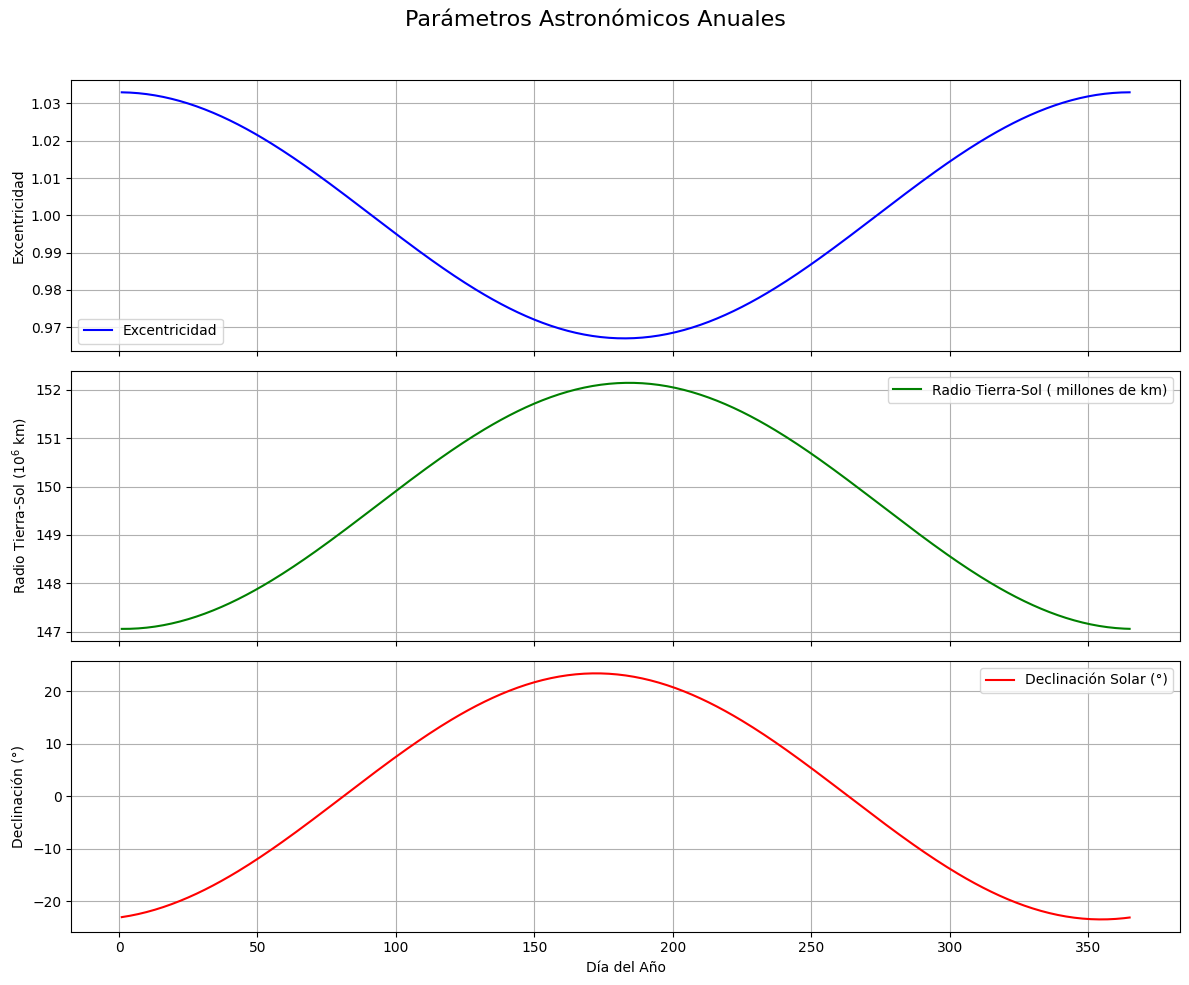

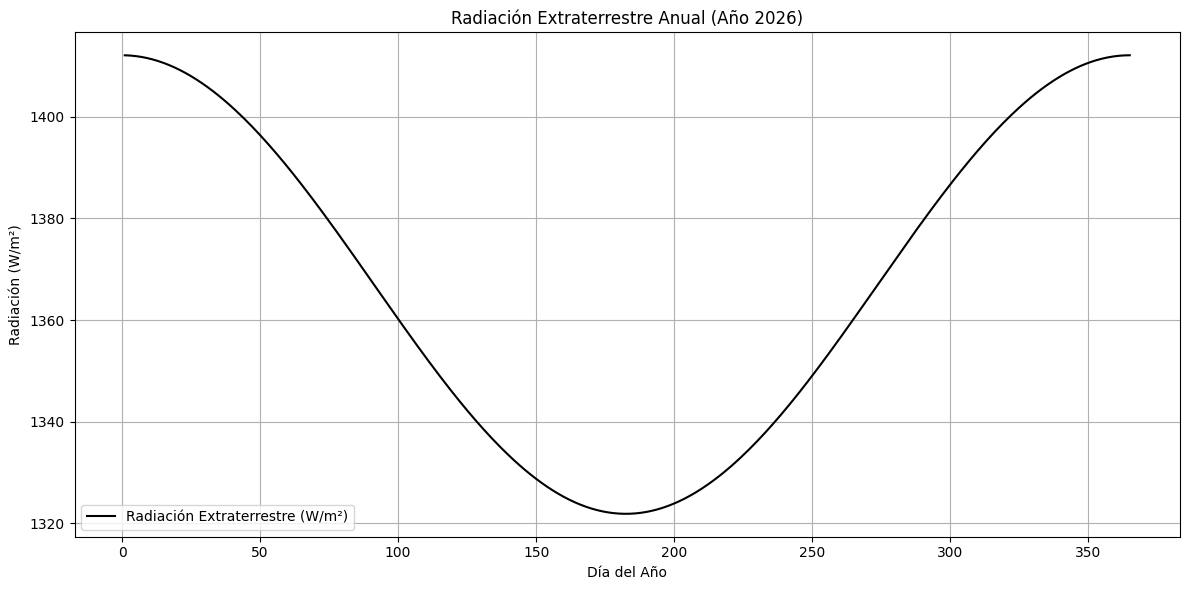

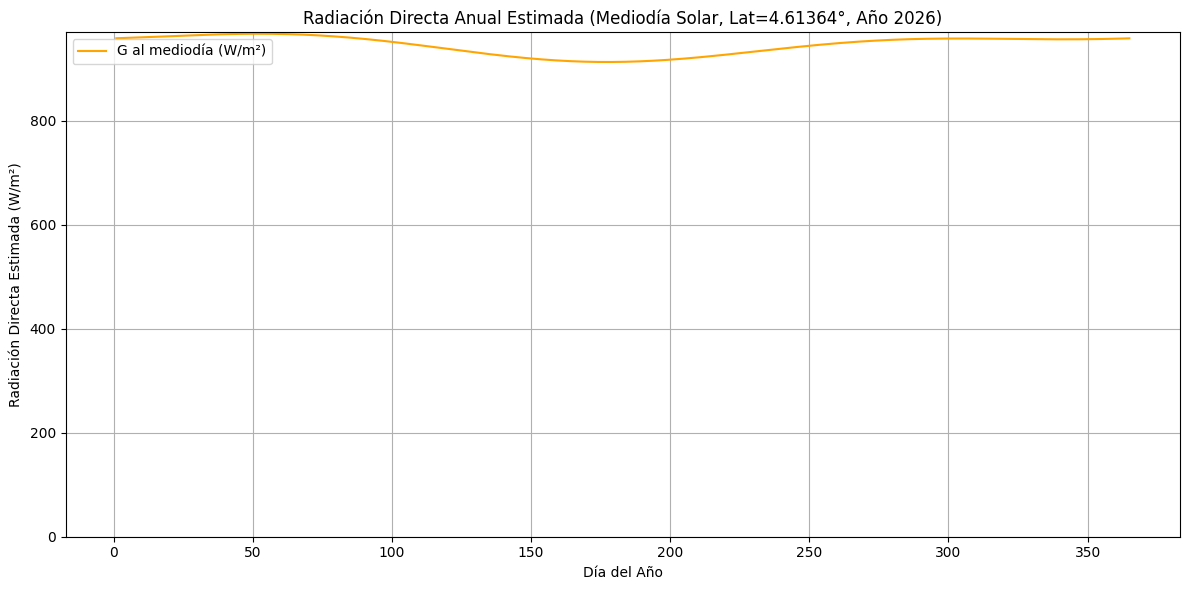


--- Resumen de Radiación al Mediodía Solar ---
Día con mayor radiación al mediodía: DN 52 (21 de February) con 967.43 W/m²
Día con menor radiación al mediodía: DN 177 (26 de June) con 913.10 W/m²
Mes con mayor radiación al mediodía: February (966.82 W/m² promedio)
Mes con menor radiación al mediodía: June (914.86 W/m² promedio)

--- Resumen de Radiación Diaria Total ---
Día con mayor radiación diaria total: DN 63 (4 de March) con 7.368 kWh/m²
Día con menor radiación diaria total: DN 174 (23 de June) con 6.419 kWh/m²


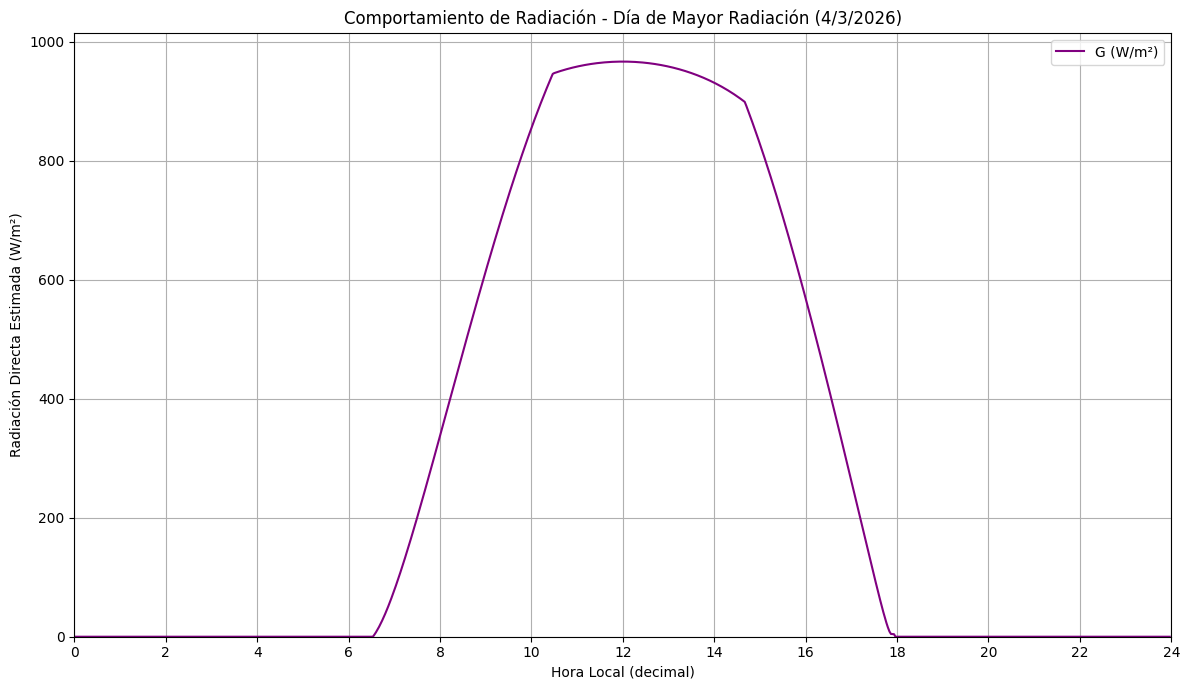


--- Análisis de Radiación para Día de Mayor Radiación (4/3/2026) ---
Ecuación de la curva (aproximada, y = ax^3 + bx^2 + cx + d):
   a = -0.409844
   b = -18.169051
   c = 644.535388
   d = -3409.461862
Integral de la función de radiación (0 a 24h, limitada 0-1000W/m²): 7377.80 Wh/m²
Promedio de radiación diaria (limitada 0-1000W/m²): 307.41 W/m²


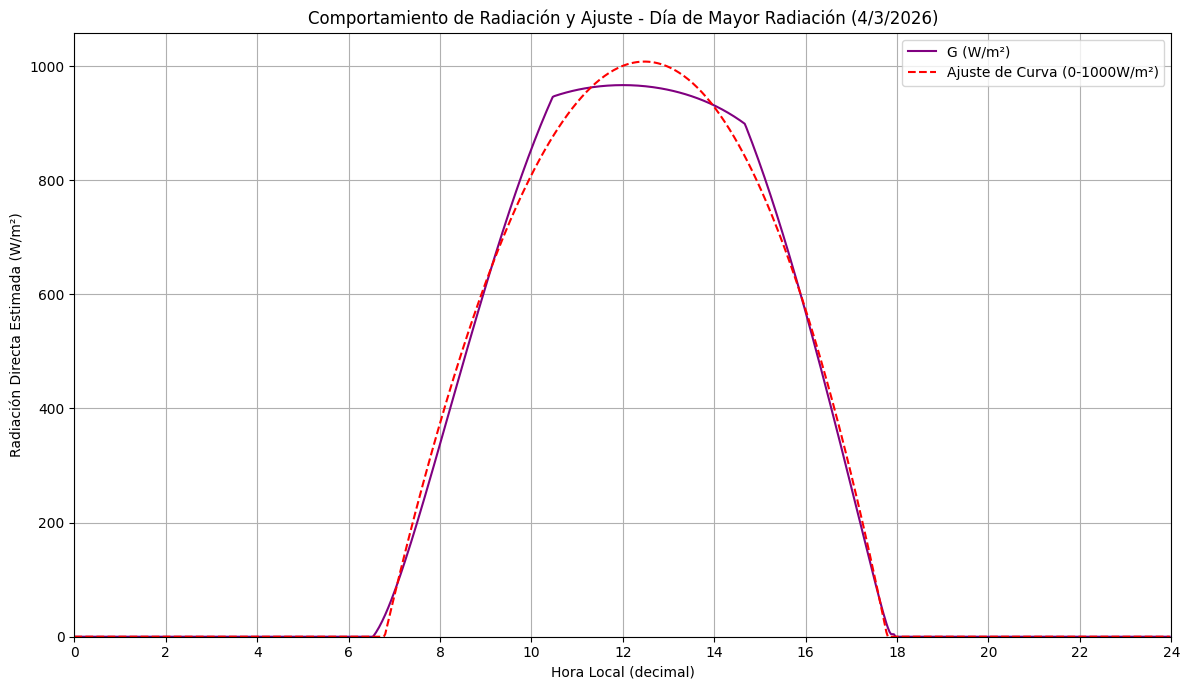

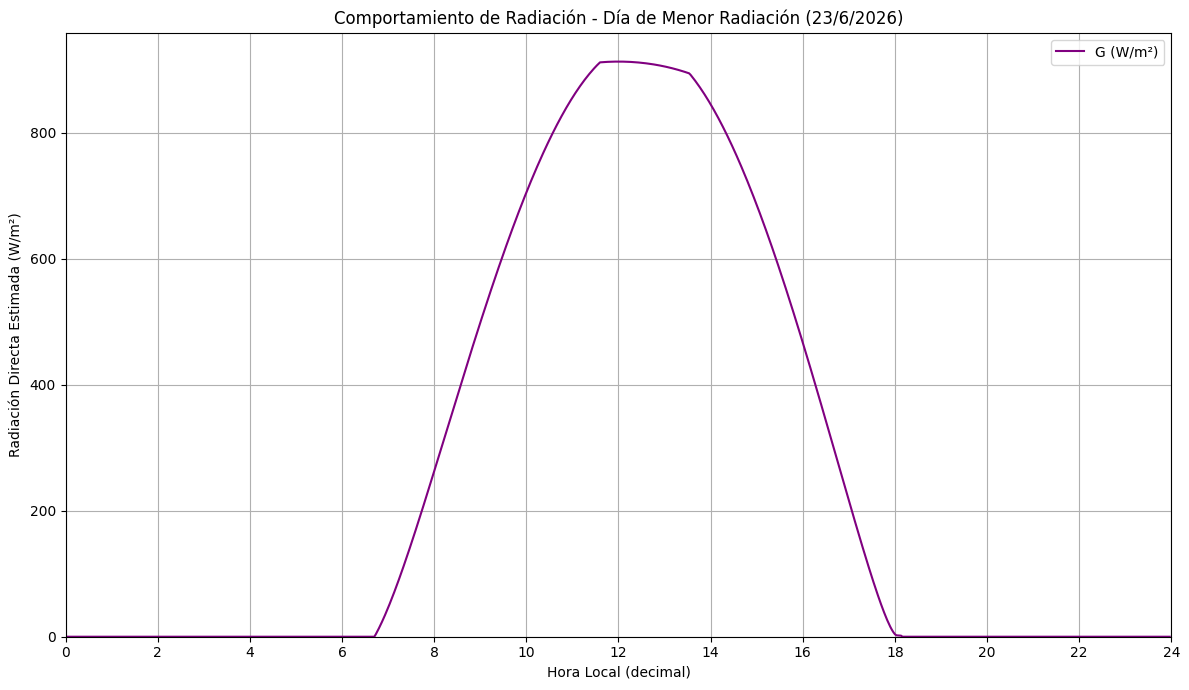


--- Análisis de Radiación para Día de Menor Radiación (23/6/2026) ---
Ecuación de la curva (aproximada, y = ax^3 + bx^2 + cx + d):
   a = -0.117829
   b = -26.687443
   c = 719.545074
   d = -3694.315503
Integral de la función de radiación (0 a 24h, limitada 0-1000W/m²): 6457.63 Wh/m²
Promedio de radiación diaria (limitada 0-1000W/m²): 269.07 W/m²


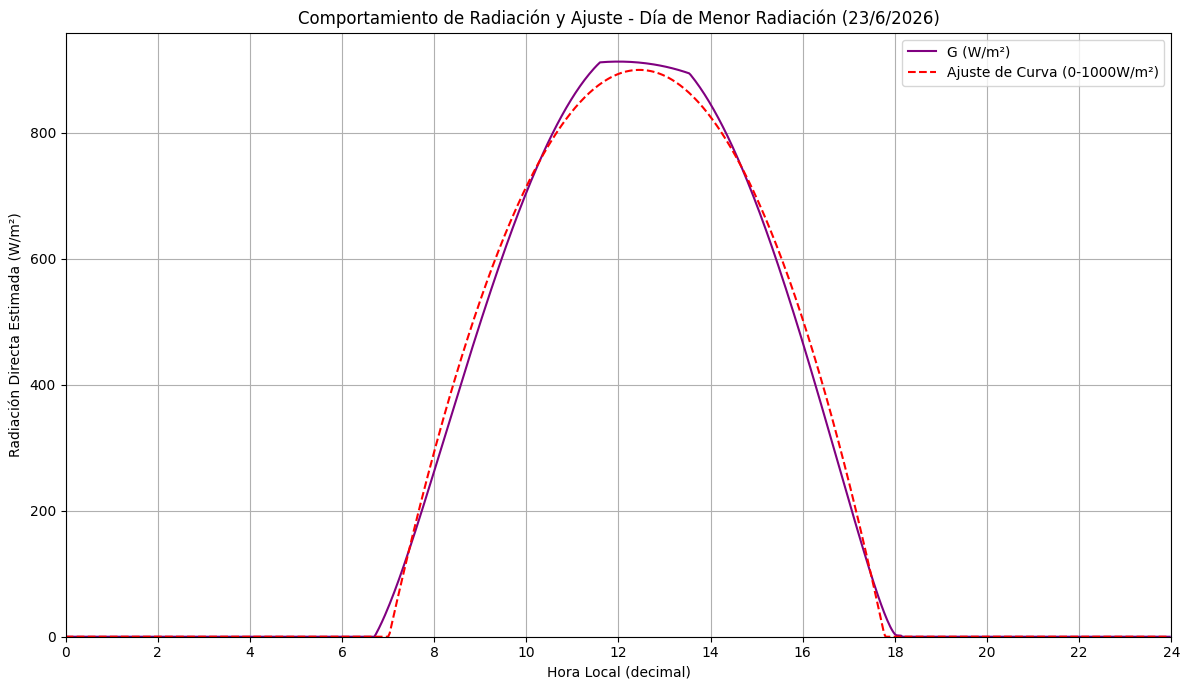

Mes con mayor radiación diaria total: March (7.334 kWh/m² promedio)
Mes con menor radiación diaria total: June (6.447 kWh/m² promedio)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import calendar
from scipy.optimize import curve_fit
from scipy.integrate import quad

# Definiendo las constantes.
Bo = 1367 # W/m^2
ro = 1.496e11 # Radio Tierra-Sol medio (m)

def es_año_bisiesto(año):
    if año % 4 == 0:
        if año % 100 == 0:
            return año % 400 == 0
        else:
            return True
    else:
        return False

def dia_del_año(dia, mes, año):
    dias_por_mes = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    if es_año_bisiesto(año):
        dias_por_mes[2] = 29

    if not (1 <= mes <= 12 and 1 <= dia <= dias_por_mes[mes]):
        return f"Fecha Inválida: Día {dia} o Mes {mes} fuera de rango para el año {año}."

    numero_dia = sum(dias_por_mes[:mes]) + dia
    return numero_dia

# --- Nueva función para convertir DN a Día/Mes
def dn_a_fecha(dn, año):
    dias_por_mes = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    if es_año_bisiesto(año):
        dias_por_mes[2] = 29

    mes = 1
    while dn > dias_por_mes[mes]:
        dn -= dias_por_mes[mes]
        mes += 1
    dia = dn
    return dia, mes

# --- Funciones de Cálculo Solar ---
def calcular_excentricidad(dn_final):
    angulo_en_radianes = np.radians((360 * dn_final) / 365)
    return 1 + 0.033 * np.cos(angulo_en_radianes)

def calcular_radio_tierra_sol(dn_final):
    angulo_en_radianes2 = np.radians((360 * (dn_final - 93)) / 365)
    return ro * (1 + 0.017 * np.sin(angulo_en_radianes2))

def calcular_declinacion(dn_final):
    return 23.45 * np.sin(np.radians((360 / 365) * (dn_final - 81)))

def calcular_radiacion_global_extraterrestre(Bo, excentricidades):
    excentricidades_np = np.array(excentricidades)
    RGE = Bo * excentricidades_np
    return RGE

def calcular_parametros_hora_especifica(dn_final, H_local, phi_grados, beta_grados, azimut_superficie_grados, declinacion_grados_precal=None, excentricidad_precal=None):
    if declinacion_grados_precal is None:
        declinacion_grados = calcular_declinacion(dn_final)
    else:
        declinacion_grados = declinacion_grados_precal

    if excentricidad_precal is None:
        excentricidad = calcular_excentricidad(dn_final)
    else:
        excentricidad = excentricidad_precal

    w_grados = 15 * (H_local - 12)

    phi_rad = np.radians(phi_grados)
    beta_rad = np.radians(beta_grados)
    azimut_superficie_rad = np.radians(azimut_superficie_grados)
    declinacion_rad = np.radians(declinacion_grados)
    w_rad = np.radians(w_grados)

    cos_theta_s = (
        np.sin(declinacion_rad) * np.sin(phi_rad) * np.cos(beta_rad)
        - np.sign(phi_grados) * np.sin(declinacion_rad) * np.cos(phi_rad) * np.sin(beta_rad) * np.cos(azimut_superficie_rad)
        + np.cos(declinacion_rad) * np.cos(phi_rad) * np.cos(beta_rad) * np.cos(w_rad)
        + np.sign(phi_grados) * np.cos(declinacion_rad) * np.sin(beta_rad) * np.cos(azimut_superficie_rad) * np.cos(w_rad)
        + np.cos(declinacion_rad) * np.sin(w_rad) * np.sin(beta_rad)
    )
    cos_theta_s = np.clip(cos_theta_s, -1.0, 1.0)

    cos_theta_zs = (
        np.sin(declinacion_rad) * np.sin(phi_rad)
        + np.cos(declinacion_rad) * np.cos(phi_rad) * np.cos(w_rad)
    )
    cos_theta_zs = np.clip(cos_theta_zs, -1.0, 1.0)

    am = None
    g = 0.0

    if cos_theta_zs > 1e-6:
        am = 1 / cos_theta_zs
        am = min(am, 38)
        if cos_theta_s > 1e-6:
            transmitancia_directa = 0.7**(am**0.678)
            g = Bo * excentricidad * transmitancia_directa * cos_theta_s
            g = max(0, g)
        else:
            g = 0.0
    else:
        g = 0.0

    return w_grados, cos_theta_s, cos_theta_zs, am, g


# --- Nueva función para calcular la radiación diaria total ---
def calcular_radiacion_diaria_total(dn_final, phi_grados, beta_grados, azimut_superficie_grados):
    horas_decimales_dia = np.arange(0, 24, 2/60) # Cada 2 minutos
    G_diaria_valores = []

    exc_dia = calcular_excentricidad(dn_final)
    dec_dia = calcular_declinacion(dn_final)

    for H_actual in horas_decimales_dia:
        _, _, _, _, g = calcular_parametros_hora_especifica(dn_final, H_actual, phi_grados, beta_grados, azimut_superficie_grados, dec_dia, exc_dia)
        G_diaria_valores.append(g if g is not None else 0)

    radiacion_diaria_kwh_m2 = np.sum(G_diaria_valores) * (2/60) / 1000
    return radiacion_diaria_kwh_m2, horas_decimales_dia, G_diaria_valores

# --- Funciones de Graficación ---
def graficar_anual_fijos(dias_año_num, excentricidades, radios_km, declinaciones, titulo_base=""):
    fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"{titulo_base}Parámetros Astronómicos Anuales", fontsize=16)

    axs[0].plot(dias_año_num, excentricidades, label='Excentricidad', color='blue')
    axs[0].set_ylabel('Excentricidad')
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(dias_año_num, radios_km, label='Radio Tierra-Sol ( millones de km)', color='green')
    axs[1].set_ylabel('Radio Tierra-Sol (10$^6$ km)')
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(dias_año_num, declinaciones, label='Declinación Solar (°)', color='red')
    axs[2].set_ylabel('Declinación (°)')
    axs[2].set_xlabel('Día del Año')
    axs[2].grid(True)
    axs[2].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def graficar_radiacion_global_anual(dias_año_num, G_anual, titulo="Radiación Directa Anual Estimada (Mediodía Solar)"):
    plt.figure(figsize=(12, 6))
    valid_indices = ~np.isnan(G_anual)
    if np.any(valid_indices):
        plt.plot(dias_año_num[valid_indices], G_anual[valid_indices], label='G al mediodía (W/m²)', color='orange')
    else:
        plt.plot([],[], label='G al mediodía (W/m²)', color='orange')
    plt.title(titulo)
    plt.xlabel('Día del Año')
    plt.ylabel('Radiación Directa Estimada (W/m²)')
    plt.legend()
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()

def graficar_radiacion_global_diaria(horas_dia, G_diaria, titulo="Radiación Directa Diaria Estimada", func_fit=None):
    plt.figure(figsize=(12, 7))
    G_diaria_np = np.array(G_diaria)
    horas_dia_np = np.array(horas_dia)

    plt.plot(horas_dia_np, G_diaria_np, label='G (W/m²)', color='purple')

    if func_fit is not None:
        # Generar puntos de la función ajustada para graficar
        # Aplicamos los límites de 0 a 1000 W/m² para la visualización del ajuste
        y_fit = func_fit(horas_dia_np)
        y_fit_clipped = np.clip(y_fit, 0, 1500) # Aplicar el clip para la gráfica

        plt.plot(horas_dia_np, y_fit_clipped, label='Ajuste de Curva (0-1000W/m²)', color='red', linestyle='--')

    plt.title(titulo)
    plt.xlabel('Hora Local (decimal)')
    plt.ylabel('Radiación Directa Estimada (W/m²)')
    plt.xticks(np.arange(0, 25, 2))
    plt.legend()
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.xlim(0, 24)
    plt.tight_layout()
    plt.show()


def graficar_radiacion_extraterrestre_anual(dias_año_num, RGE, titulo="Radiación Extraterrestre Anual"):
    plt.figure(figsize=(12, 6))
    plt.plot(dias_año_num, RGE, label='Radiación Extraterrestre (W/m²)', color='black')
    plt.title(titulo)
    plt.xlabel('Día del Año')
    plt.ylabel('Radiación (W/m²)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
# --- Nuevas funciones de ajuste e integración ---
def radiation_model(x, a, b, c, d):
    # Un modelo de función para la radiación (ejemplo: polinomio de grado 3)
    # Se puede ajustar para usar funciones trigonométricas si se espera un comportamiento periódico
    return a * x**3 + b * x**2 + c * x + d

def fit_and_integrate_radiation(horas, radiacion_valores, title_suffix=""):
    # Convertir radiacion_valores a un array de NumPy antes de la comparación
    radiacion_valores_np = np.array(radiacion_valores)
    # Filtrar valores de radiación válidos (mayores que un umbral pequeño) para el ajuste
    valid_indices = np.where(radiacion_valores_np > 1.0) # Considerar solo cuando hay radiación significativa
    horas_validas = horas[valid_indices]
    radiacion_validas = radiacion_valores_np[valid_indices] # Usar el array NumPy aquí también

    if len(horas_validas) < 4: # Necesitamos al menos 4 puntos para un polinomio de grado 3
        print(f"No hay suficientes puntos para ajustar la curva para {title_suffix}.")
        return None, None, None

    try:
        # Intentar ajustar la curva
        popt, pcov = curve_fit(radiation_model, horas_validas, radiacion_validas, maxfev=5000)

        # La función para integrar, aplicando los límites deseados
        def func_to_integrate_clipped(x_val):
            y_val = radiation_model(x_val, *popt)
            # Solo devuelve el valor si está dentro del rango [0, 1000]
            # De lo contrario, devuelve 0 para no contribuir a la integral
            return np.clip(y_val, 0, 1000) # Clip entre 0 y 1000

        # Integrar la función desde 0 hasta 24 horas
        integral_result, error = quad(func_to_integrate_clipped, 0, 24)

        # El promedio de radiación es la integral dividida por el rango de tiempo (24 horas)
        average_radiation = integral_result / 24

        print(f"\n--- Análisis de Radiación para {title_suffix} ---")
        print(f"Ecuación de la curva (aproximada, y = ax^3 + bx^2 + cx + d):")
        print(f"   a = {popt[0]:.6f}")
        print(f"   b = {popt[1]:.6f}")
        print(f"   c = {popt[2]:.6f}")
        print(f"   d = {popt[3]:.6f}")
        print(f"Integral de la función de radiación (0 a 24h, limitada 0-1000W/m²): {integral_result:.2f} Wh/m²")
        print(f"Promedio de radiación diaria (limitada 0-1000W/m²): {average_radiation:.2f} W/m²")

        # Devolver la función original `radiation_model` para que la gráfica muestre el ajuste sin recortar,
        # y la gráfica de `func_fit` aplicará el clip para la visualización.
        # Si quieres que func_fit en la gráfica sea la función recortada, devuelve func_to_integrate_clipped
        return lambda x: radiation_model(x, *popt), integral_result, average_radiation

    except RuntimeError as e:
        print(f"No se pudo realizar el ajuste de curva para {title_suffix}: {e}")
        return None, None, None
    except ValueError as e:
        print(f"Error en los datos para el ajuste de curva para {title_suffix}: {e}")
        return None, None, None


def main():
    tipo_calculo = input("¿Desea hacer un cálculo para una hora específica (h), un día específico (d), para todo el año (a), o cálculo de paneles solares (p)? (h/d/a/p): ").lower()

    if tipo_calculo not in ['h', 'd', 'a', 'p']:
        print("Tipo de cálculo no válido. Seleccione 'h', 'd', 'a' o 'p'.")
        return

    # --- Variables para almacenar los datos del día de menor radiación ---
    dn_min_rad = -1
    dia_min_rad = -1
    mes_min_rad = -1
    horas_min_rad = []
    valores_min_rad = []
    min_g_diaria_total = float('inf')

    # --- Variables para parámetros de ubicación y año (comunes a todos los modos) ---
    año = 0
    phi_grados = 0
    beta_grados = 0
    azimut_superficie_grados = 0

    # --- Solicitud de datos iniciales para cualquier tipo de cálculo que requiera parámetros geográficos o anuales ---
    if tipo_calculo in ['a', 'p']:
        año = int(input("Por favor introduzca el año: "))
        phi_grados = float(input("Por favor introduzca el valor de la latitud (en grados [-90 a 90]): "))
        beta_grados = float(input("Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): "))
        azimut_superficie_grados = float(input("Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): "))
    elif tipo_calculo in ['d', 'h']:
        fecha_str = input("Por favor introduce la fecha (DD MM) para el cálculo de radiación: ")
        año = int(input("Por favor introduzca el año: "))
        try:
            dia_n, mes_n = fecha_str.split()
            dia = int(dia_n)
            mes = int(mes_n)
        except ValueError:
            print("Formato de fecha incorrecto. Use DD MM.")
            return
        dn_final = dia_del_año(dia, mes, año)
        if isinstance(dn_final, str):
            print(dn_final)
            return
        phi_grados = float(input("Por favor introduzca el valor de la latitud (en grados [-90 a 90]): "))
        beta_grados = float(input("Por favor introduzca la inclinación de la superficie beta (en grados [0 a 180]): "))
        azimut_superficie_grados = float(input("Por favor introduzca el valor del azimut de la normal a la superficie respecto al sur astronómico (en grados [-180 a 180], Sur=0, Oeste=90, Este=-90): "))
        if tipo_calculo == 'h':
            H_local = float(input("Por favor introduzca el valor de la hora local (en horas decimales, e.g., 13.5 para 1:30 PM): "))


    if tipo_calculo == 'a' or tipo_calculo == 'p': # Calcular datos anuales para encontrar el día de menor radiación
        num_dias_año = 366 if es_año_bisiesto(año) else 365
        dias_año_indices = np.arange(1, num_dias_año + 1)

        excentricidades_anuales = []
        radios_anuales_km = []
        declinaciones_anuales = []
        G_mediodia_anual = []
        G_diaria_total_anual = [] # Lista para almacenar la radiación diaria total

        print(f"\nCalculando parámetros para el año {año}:")
        print("------------------------------------------------------------------------------------")
        print("Día | Excentricidad | Radio (10^6 km) | Declinación (°) | G_mediodia (W/m²) | G_diaria_total (kWh/m²)")
        print("----|---------------|-----------------|-----------------|-------------------|-----------------------")

        dn_max_rad = -1 # Para el día de mayor radiación, si se necesita para contexto
        max_g_diaria_total = -1
        horas_max_rad = []
        valores_max_rad = []

        for dn in dias_año_indices:
            exc = calcular_excentricidad(dn)
            rad_m = calcular_radio_tierra_sol(dn)
            dec = calcular_declinacion(dn)

            # Cálculo de la radiación al mediodía solar
            _, _, _, _, g_mediodia = calcular_parametros_hora_especifica(dn, 12.0, phi_grados, beta_grados, azimut_superficie_grados, dec, exc)

            # Cálculo de la radiación diaria total y los valores minuto a minuto
            g_diaria_total, horas_valores, g_valores = calcular_radiacion_diaria_total(dn, phi_grados, beta_grados, azimut_superficie_grados)

            excentricidades_anuales.append(exc)
            radios_anuales_km.append(rad_m / 1e9)
            declinaciones_anuales.append(dec)
            G_mediodia_anual.append(g_mediodia if g_mediodia is not None else np.nan)
            G_diaria_total_anual.append(g_diaria_total) # Añadir a la lista

            if g_diaria_total < min_g_diaria_total:
                min_g_diaria_total = g_diaria_total
                dn_min_rad = dn
                dia_min_rad, mes_min_rad = dn_a_fecha(dn_min_rad, año)
                horas_min_rad = horas_valores
                valores_min_rad = g_valores

            if g_diaria_total > max_g_diaria_total: # También guardar el día de mayor radiación para gráficos/análisis
                max_g_diaria_total = g_diaria_total
                dn_max_rad = dn
                horas_max_rad = horas_valores
                valores_max_rad = g_valores


            print(f"{dn:3d} | {exc:13.4f} | {rad_m/1e9:15.3f} | {dec:15.2f} | {(f'{g_mediodia:.2f}' if g_mediodia is not None else 'N/A'):>17} | {g_diaria_total:21.3f}")
        print("------------------------------------------------------------------------------------")

        graficar_anual_fijos(dias_año_indices, excentricidades_anuales, radios_anuales_km, declinaciones_anuales)
        # --- Cálculo y gráfica de radiación extraterrestre ---
        RGE_anual = calcular_radiacion_global_extraterrestre(Bo, excentricidades_anuales)
        graficar_radiacion_extraterrestre_anual(dias_año_indices,RGE_anual,titulo=f"Radiación Extraterrestre Anual (Año {año})")
        graficar_radiacion_global_anual(dias_año_indices, np.array(G_mediodia_anual),
                                         titulo=f"Radiación Directa Anual Estimada (Mediodía Solar, Lat={phi_grados}°, Año {año})")

        # --- Resumen de Radiación al Mediodía Solar ---
        if np.any(~np.isnan(G_mediodia_anual)):
            max_g_mediodia = np.nanmax(G_mediodia_anual)
            min_g_mediodia = np.nanmin(G_mediodia_anual)

            idx_max_g_mediodia_dn = np.where(G_mediodia_anual == max_g_mediodia)[0][0] + 1
            idx_min_g_mediodia_dn = np.where(G_mediodia_anual == min_g_mediodia)[0][0] + 1

            dia_max_mediodia, mes_max_mediodia = dn_a_fecha(idx_max_g_mediodia_dn, año)
            dia_min_mediodia, mes_min_mediodia = dn_a_fecha(idx_min_g_mediodia_dn, año)


            print("\n--- Resumen de Radiación al Mediodía Solar ---")
            print(f"Día con mayor radiación al mediodía: DN {idx_max_g_mediodia_dn} ({dia_max_mediodia} de {calendar.month_name[mes_max_mediodia]}) con {max_g_mediodia:.2f} W/m²")
            print(f"Día con menor radiación al mediodía: DN {idx_min_g_mediodia_dn} ({dia_min_mediodia} de {calendar.month_name[mes_min_mediodia]}) con {min_g_mediodia:.2f} W/m²")

            # Calcular radiación promedio mensual al mediodía
            radiacion_mensual_mediodia = {}
            dias_por_mes_anual = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
            if es_año_bisiesto(año):
                dias_por_mes_anual[2] = 29

            current_day_index = 0
            for i in range(1, 13):
                month_days = dias_por_mes_anual[i]
                monthly_radiation = [G_mediodia_anual[current_day_index + j] for j in range(month_days) if (current_day_index + j < len(G_mediodia_anual)) and not np.isnan(G_mediodia_anual[current_day_index + j])]
                if monthly_radiation:
                    radiacion_mensual_mediodia[i] = np.mean(monthly_radiation)
                else:
                    radiacion_mensual_mediodia[i] = np.nan
                current_day_index += month_days

            if radiacion_mensual_mediodia:
                valid_months_mediodia = {m: r for m, r in radiacion_mensual_mediodia.items() if not np.isnan(r)}
                if valid_months_mediodia:
                    max_mes_mediodia = max(valid_months_mediodia, key=valid_months_mediodia.get)
                    min_mes_mediodia = min(valid_months_mediodia, key=valid_months_mediodia.get)

                    print(f"Mes con mayor radiación al mediodía: {calendar.month_name[max_mes_mediodia]} ({radiacion_mensual_mediodia[max_mes_mediodia]:.2f} W/m² promedio)")
                    print(f"Mes con menor radiación al mediodía: {calendar.month_name[min_mes_mediodia]} ({radiacion_mensual_mediodia[min_mes_mediodia]:.2f} W/m² promedio)")
                else:
                    print("No hay datos válidos para calcular la radiación promedio mensual al mediodía.")


        # --- Análisis de radiación diaria total anual ---
        if np.any(~np.isnan(G_diaria_total_anual)):

            print("\n--- Resumen de Radiación Diaria Total ---")
            print(f"Día con mayor radiación diaria total: DN {dn_max_rad} ({dn_a_fecha(dn_max_rad, año)[0]} de {calendar.month_name[dn_a_fecha(dn_max_rad, año)[1]]}) con {max_g_diaria_total:.3f} kWh/m²")
            print(f"Día con menor radiación diaria total: DN {dn_min_rad} ({dia_min_rad} de {calendar.month_name[mes_min_rad]}) con {min_g_diaria_total:.3f} kWh/m²")

            # Graficar y determinar la ecuación para el día de mayor radiación
            graficar_radiacion_global_diaria(horas_max_rad, valores_max_rad, titulo=f"Comportamiento de Radiación - Día de Mayor Radiación ({dn_a_fecha(dn_max_rad, año)[0]}/{dn_a_fecha(dn_max_rad, año)[1]}/{año})")
            func_max_rad, integral_max_rad, avg_max_rad = fit_and_integrate_radiation(horas_max_rad, valores_max_rad, f"Día de Mayor Radiación ({dn_a_fecha(dn_max_rad, año)[0]}/{dn_a_fecha(dn_max_rad, año)[1]}/{año})")
            if func_max_rad:
                graficar_radiacion_global_diaria(horas_max_rad, valores_max_rad,
                                                 titulo=f"Comportamiento de Radiación y Ajuste - Día de Mayor Radiación ({dn_a_fecha(dn_max_rad, año)[0]}/{dn_a_fecha(dn_max_rad, año)[1]}/{año})",
                                                 func_fit=func_max_rad)

            # Graficar y determinar la ecuación para el día de menor radiación
            graficar_radiacion_global_diaria(horas_min_rad, valores_min_rad, titulo=f"Comportamiento de Radiación - Día de Menor Radiación ({dia_min_rad}/{mes_min_rad}/{año})")
            func_min_rad, integral_min_rad, avg_min_rad = fit_and_integrate_radiation(horas_min_rad, valores_min_rad, f"Día de Menor Radiación ({dia_min_rad}/{mes_min_rad}/{año})")
            if func_min_rad:
                graficar_radiacion_global_diaria(horas_min_rad, valores_min_rad,
                                                 titulo=f"Comportamiento de Radiación y Ajuste - Día de Menor Radiación ({dia_min_rad}/{mes_min_rad}/{año})",
                                                 func_fit=func_min_rad)


            # Calcular radiación promedio mensual diaria total
            radiacion_mensual_diaria_total = {}
            current_day_index = 0
            for i in range(1, 13):
                month_days = dias_por_mes_anual[i]
                monthly_radiation = [G_diaria_total_anual[current_day_index + j] for j in range(month_days) if (current_day_index + j < len(G_diaria_total_anual)) and not np.isnan(G_diaria_total_anual[current_day_index + j])]
                if monthly_radiation:
                    radiacion_mensual_diaria_total[i] = np.mean(monthly_radiation)
                else:
                    radiacion_mensual_diaria_total[i] = np.nan
                current_day_index += month_days

            if radiacion_mensual_diaria_total:
                valid_months_diaria_total = {m: r for m, r in radiacion_mensual_diaria_total.items() if not np.isnan(r)}
                if valid_months_diaria_total:
                    max_mes_diaria_total = max(valid_months_diaria_total, key=valid_months_diaria_total.get)
                    min_mes_diaria_total = min(valid_months_diaria_total, key=valid_months_diaria_total.get)

                    print(f"Mes con mayor radiación diaria total: {calendar.month_name[max_mes_diaria_total]} ({radiacion_mensual_diaria_total[max_mes_diaria_total]:.3f} kWh/m² promedio)")
                    print(f"Mes con menor radiación diaria total: {calendar.month_name[min_mes_diaria_total]} ({radiacion_mensual_diaria_total[min_mes_diaria_total]:.3f} kWh/m² promedio)")
                else:
                    print("No hay datos válidos para calcular la radiación promedio mensual diaria total.")

    if tipo_calculo == 'p':
        print("\n--- Información del Panel Solar ---")
        potencia_pico_panel = float(input("Ingrese la potencia pico del panel solar (en W): "))
        eficiencia_panel = float(input("Ingrese el porcentaje de eficiencia del panel solar (ej. 20 para 20%): ")) / 100
        area_panel = float(input("Ingrese el área del panel solar (en m²): "))

        potencia_salida_panel = potencia_pico_panel * eficiencia_panel
        potencia_por_area = potencia_salida_panel / area_panel if area_panel > 0 else 0

        print(f"\nPotencia de salida total por panel: {potencia_salida_panel:.2f} W")
        print(f"Potencia por área del panel: {potencia_por_area:.2f} W/m²")

        print("\n--- Información de Consumo Eléctrico ---")
        consumo_mensual_kwh = float(input("Ingrese el consumo de electricidad de su recibo del mes de mayor gasto (en kWh): "))
        # Obtener los días de ese mes para calcular el consumo diario más alto
        mes_mayor_gasto = int(input("Ingrese el número del mes (1-12) en el que tuvo el mayor gasto: "))

        # Validar el mes
        if not (1 <= mes_mayor_gasto <= 12):
            print("Número de mes inválido.")
            return

        dias_del_mes_mayor_gasto = calendar.monthrange(año, mes_mayor_gasto)[1] # Obtiene el número de días del mes

        # Consumo diario promedio para el mes de mayor gasto (kWh/día)
        consumo_diario_promedio_kwh = consumo_mensual_kwh / dias_del_mes_mayor_gasto

        # Consumo objetivo (suplir y superar en un 20%)
        consumo_diario_objetivo_kwh = consumo_diario_promedio_kwh * 1.20 # kWh/día

        print(f"\nConsumo diario promedio en el mes de mayor gasto ({calendar.month_name[mes_mayor_gasto]}): {consumo_diario_promedio_kwh:.2f} kWh/día")
        print(f"Consumo diario objetivo (incluyendo 20% extra): {consumo_diario_objetivo_kwh:.2f} kWh/día")

        # Usar la radiación del día con menor radiación anual
        radiacion_total_dia_kwh_m2_min_rad = min_g_diaria_total

        if radiacion_total_dia_kwh_m2_min_rad <= 0:
            print(f"Advertencia: La radiación diaria total en el día de menor radiación ({dia_min_rad}/{mes_min_rad}/{año}) es cero o negativa. No se pueden calcular los paneles. Revise la latitud, inclinación y azimut.")
            return

        # Energía diaria producible por un solo panel (kWh/día) en el día de menor radiación
        energia_diaria_por_panel_kwh = (potencia_salida_panel / 1000) * radiacion_total_dia_kwh_m2_min_rad
        hsp = integral_min_rad / 1000
        if energia_diaria_por_panel_kwh <= 0:
            print("La energía diaria producida por un panel es cero o negativa. Revise los datos de entrada.")
            return

        print(f"Energía generada por un panel al día (basado en el día de menor radiación: {dia_min_rad}/{mes_min_rad}/{año}): {energia_diaria_por_panel_kwh:.2f} kWh/día")
        print(f"La hora solar obtenida es: {hsp}")
        return # Detiene la ejecución aquí

    elif tipo_calculo == 'd':
        # dn_final, dia, mes ya están definidos al inicio
        print(f"\nCalculando para el día {dia}/{mes}/{año} (Día del año: {dn_final}):")
        print(f"Latitud: {phi_grados}°, Inclinación: {beta_grados}°, Azimut Superficie: {azimut_superficie_grados}°")
        print("--------------------------------------------------------------------------")
        print("Hora    | w (°) | cos(θs) | cos(θzs) |   AM   | G (W/m²)")
        print("--------|-------|---------|----------|--------|----------")

        radiacion_total_dia_kwh_m2, horas_decimales_dia, G_diaria = calcular_radiacion_diaria_total(dn_final, phi_grados, beta_grados, azimut_superficie_grados)

        exc_dia = calcular_excentricidad(dn_final)
        dec_dia = calcular_declinacion(dn_final)
        print(f"Excentricidad del día: {exc_dia:.4f}, Declinación del día: {dec_dia:.2f}°\n")

        # Re-imprimir los valores detallados si es necesario, o asumir que ya fueron calculados en G_diaria
        for i, H_actual in enumerate(horas_decimales_dia):
            w_grados, cos_theta_s, cos_theta_zs, am, g = \
                calcular_parametros_hora_especifica(dn_final, H_actual, phi_grados, beta_grados, azimut_superficie_grados, dec_dia, exc_dia)

            hora_h = int(H_actual)
            min_m = int(round((H_actual * 60) % 60))
            hora_reloj_str = f"{hora_h:02d}:{min_m:02d}"

            am_str = f"{am:6.2f}" if am is not None else "   -   "
            g_str = f"{g:8.2f}" if g is not None else "     -  "
            print(f"{hora_reloj_str:8}| {w_grados:5.1f} | {cos_theta_s:7.3f} | {cos_theta_zs:8.3f} | {am_str} | {g_str}")
        print("--------------------------------------------------------------------------")

        print(f"\nRadiación directa total para el día {dia}/{mes}/{año}: {radiacion_total_dia_kwh_m2:.3f} kWh/m²")

        graficar_radiacion_global_diaria(horas_decimales_dia, G_diaria,
                                          titulo=f"Radiación Directa Estimada - {dia}/{mes}/{año} (Lat={phi_grados}°)")

        print("\nGenerando gráfica de radiación anual (mediodía) para contexto...")
        num_dias_año_actual = 366 if es_año_bisiesto(año) else 365
        dias_año_actual_indices = np.arange(1, num_dias_año_actual + 1)
        G_mediodia_contexto_anual = []
        for dn_temp in dias_año_actual_indices:
            exc_temp = calcular_excentricidad(dn_temp)
            dec_temp = calcular_declinacion(dn_temp)
            _, _, _, _, g_temp = calcular_parametros_hora_especifica(dn_temp, 12.0, phi_grados, beta_grados, azimut_superficie_grados, dec_temp, exc_temp)
            G_mediodia_contexto_anual.append(g_temp if g_temp is not None else np.nan)

        graficar_radiacion_global_anual(dias_año_actual_indices, np.array(G_mediodia_contexto_anual),
                                         titulo=f"Contexto: Rad. Directa Anual Estimada (Mediodía, Lat={phi_grados}°, Año {año})")


    elif tipo_calculo == 'h':
        # dn_final, H_local, dia, mes ya están definidos al inicio
        exc = calcular_excentricidad(dn_final)
        rad_m = calcular_radio_tierra_sol(dn_final)
        dec = calcular_declinacion(dn_final)

        w_grados, cos_theta_s, cos_theta_zs, am, g = \
            calcular_parametros_hora_especifica(dn_final, H_local, phi_grados, beta_grados, azimut_superficie_grados, dec, exc)

        print(f"\nResultados para {dia}/{mes}/{año} a las {H_local:.2f} horas (Día del año: {dn_final}):")
        print(f"Latitud: {phi_grados}°, Inclinación: {beta_grados}°, Azimut Sup.: {azimut_superficie_grados}°")
        print("----------------------------------------------------")
        print(f"Excentricidad:                         {exc:.5f}")
        print(f"Radio Tierra-Sol (10^6 km):            {rad_m/1e9:.3f}")
        print(f"Declinación Solar (grados):            {dec:.2f}")
        print(f"Ángulo Horario w (grados):             {w_grados:.2f}")
        print(f"Coseno Ángulo Incidencia (θs):         {cos_theta_s:.4f}")
        print(f"Coseno Ángulo Cenital (θzs):           {cos_theta_zs:.4f}")
        if am is not None:
            print(f"Masa de Aire (AM):                     {am:.2f}")
            print(f"Radiación Directa G (W/m²):            {g:.2f}")
        else:
            if cos_theta_zs <= 1e-6:
                print("El Sol está por debajo del horizonte. No se calcula AM ni Radiación.")
            else:
                print("Masa de Aire y Radiación no calculables bajo las condiciones dadas (e.g. superficie no ve el sol).")
        print("----------------------------------------------------")

if __name__ == "__main__":
    main()